In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from scipy.stats import spearmanr
import seaborn as sns


In [3]:
def plot_redundancy(data, title='Dataset Redundancy Check (IDA)'):
    """
    Visualises variable redundancy using hierarchical clustering based on 
    Spearman rank correlation. Columns with zero variance are automatically 
    excluded. All variable types (categorical, numeric, boolean) are handled 
    via factorization before correlation is computed.
    
    Parameters
    ----------
    data : pd.DataFrame
        Input dataset. All column types are supported.
    title : str
        Plot title. Default: 'Dataset Redundancy Check (IDA)'.
    
    Returns
    -------
    None. Displays a dendrogram where variables that cluster together 
    at low distance values carry redundant information and are candidates 
    for exclusion or consolidation.
    
    Notes
    -----
    - Distance = 1 - |Spearman r|, so distance = 0 means perfect correlation.
    - Clustering method: 'complete' linkage (max distance between clusters).
    - Variables with a single unique value are dropped before computation.
    """
    dataset = data.copy()
    dataset = dataset.loc[:, dataset.nunique() > 1]
    
    dataset_numeric = dataset.apply(lambda x: pd.factorize(x)[0])
    
    corr_matrix, _ = spearmanr(dataset_numeric)
    corr_matrix = np.nan_to_num(corr_matrix)
    
    distance_matrix = 1 - np.abs(corr_matrix)
    dist_linkage = hierarchy.linkage(distance_matrix, method='complete')
    
    fig, ax = plt.subplots(figsize=(12, 12))
    hierarchy.dendrogram(
        dist_linkage,
        labels=dataset.columns.tolist(),
        ax=ax,
        orientation='right',
        leaf_font_size=10
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Betting Market Perception of Referee Bias in NBA Close Games

## 1. Abstract

This study examines whether home court referee bias in NBA close games is reflected in betting market outcomes. Using NBA Last Two Minute (L2M) reports [AtlhawksfanaticL2M] as ground truth for referee error direction, we first replicate and extend the methodology of Pelechrinis (2023) [PelechrinisL2M] across three periods defined by crowd presence conditions: Pre-COVID (2015–2019), COVID (2020–2022), and Post-COVID (2023–2025). Referee errors are aggregated to the game level via the Net Whistle Gain (NWG) metric and linked to pre-game point spreads and cover outcomes from independent bookmakers [KaggleBetting]. The central question is whether games in which referees systematically erred in favor of the home team correspond to higher home spread coverage rates — a pattern that would suggest betting markets either fail to account for referee bias or partially incorporate it. The COVID-19 period, during which games were played without fans, serves as a natural experiment for isolating the crowd pressure mechanism.

## 2. Introduction
Referee decisions in professional sports are not made in a vacuum. Research has documented systematic patterns in how referees make errors — favoring home teams [ErikstadJohansen2020] and higher-status players [Barrett2021]. This study examines whether these patterns are detectable not only in officiating data, but in the outcomes of betting markets as well.

### 2.1 Background
Home court bias is the most studied form of referee bias in professional sports. Crowd noise and social pressure from home fans have been linked to systematic differences in foul calls favoring the home team [ErikstadJohansen2020]. In the NBA specifically, Pelechrinis (2023) showed that this effect disappears when games are played without fans [PelechrinisL2M] — a strong indicator that the crowd, not the home team itself, is the driving factor.

The COVID-19 pandemic (seasons 2020–2022), during which NBA games were played without fans or with severely restricted attendance, provides a natural experiment within the dataset. If bias is driven by social pressure, it should diminish during this period — a prediction that is directly testable with the available data.

### 2.2 Related Work
Belasen et al. (2025) examine the same L2M data and find that referees make significantly fewer incorrect calls against underdogs than against favorites — suggesting that betting market status is associated with the direction of referee errors [BelasenL2M2025]. This study approaches the question from a complementary direction: rather than testing whether market expectations predict referee errors, we test whether referee errors predict betting outcomes.

Together, the two studies provide convergent evidence for the same underlying phenomenon: referee bias and market pricing are two independent signals of the same structural pattern — home advantage under conditions of high psychological intensity. The direction of measurement is less important than its existence: both independent data sources point to the same systemic effect.

### 2.3 Research Design
To test the central hypothesis, two independent data sources are used. The primary dataset is the NBA Last Two Minute (L2M) reports [AtlhawksfanaticL2M], which provide a unique ground truth — every referee decision in the final two minutes of close games is graded as correct or incorrect by the NBA league office itself. Referee errors are aggregated to the game level via the Net Whistle Gain (NWG) metric.

Betting market data [KaggleBetting] provides pre-game point spreads and post-game cover outcomes set by independent bookmakers with no access to L2M grades. The relationship between game-level NWG and spread coverage rates is then examined.

## 3. Methodology & Hypotheses

### 3.1 The Logic of Structural Convergence

Pelechrinis (2023) establishes that NBA referees systematically favour the home team in close games — an effect that disappears when crowds are absent. This suggests that home-court advantage is not merely physical, but a psychological byproduct of crowd pressure.

We extend this logic to the betting market. If a full arena influences the split-second decisions of referees, it likely influences the collective judgment of bookmakers and bettors as well. We hypothesize that referee errors and market pricing are two independent signals of the same phenomenon: crowd pressure in close home games.

Under Structural Convergence, as crowd pressure increases we expect both a rise in referee errors favouring the home team (positive NWG) and a simultaneous failure of the home team to cover the market's inflated expectations.

### 3.2 Key Variables & Definitions

Before formalizing the hypotheses, we define the two primary metrics used throughout the analysis.

**Net Whistle Gain (NWG)** — the net difference between referee errors favouring the home team and referee errors favouring the away team in the final two minutes of a close game. A positive NWG indicates realized referee bias toward the home team. Formally:

$$\beta = |INC : committing\_side = home| + |IC : disadvantaged\_side = home|$$
$$\delta = |INC : disadvantaged\_side = home| + |IC : committing\_side = home|$$
$$NWG = \beta - \delta$$

**Cover Rate** — a binary outcome indicating whether the home team beat the point spread set by bookmakers before the game:

$$cover = \begin{cases} 1 & \text{if home team beat the spread} \\ 0 & \text{if home team did not beat the spread} \\ \text{excluded} & \text{if margin} = \text{spread (push)} \end{cases}$$

**Asymmetry Ratio (AR)** — NWG expressed as a proportion:

$$AR = \frac{\beta}{\beta + \delta}$$

$AR = 0.5$ indicates no bias. $AR > 0.5$ indicates home bias. Undefined when there are zero errors in a game.

### 3.3 Formal Statistical Framework

To test the efficiency of the betting market under conditions of home bias, we establish two hypotheses.

#### 3.3.1 Auxiliary Hypothesis

Before testing the central hypothesis, we must confirm that home court referee bias exists in the data. Following Pelechrinis (2023) [PelechrinisL2M], we adopt a one-tailed test:

$$H_0^{aux}: E[NWG] \leq 0 \quad \text{(no systematic home court referee bias)}$$
$$H_1^{aux}: E[NWG] > 0 \quad \text{(referee errors systematically favour the home team)}$$

The empirical p-value is defined as:

$$p = \frac{|\{t_{sim} \geq t_{real}\}|}{n_{sim}}$$

where $t_{real}$ is the observed sum of NWG and $t_{sim}$ is the simulated sum under $H_0$, generated via Monte Carlo simulation following Pelechrinis (2023) [PelechrinisCode].

This is tested across three periods defined by crowd presence conditions:

- **Pre-COVID** (2015–2019): Full capacity arenas.
- **COVID** (2020–2022): Restricted capacity — natural experiment.
- **Post-COVID** (2023–2025): Full capacity arenas restored.

#### 3.3.2 Central Hypothesis

The central question is whether the betting market efficiently prices home-court referee bias.

**H₀ — "The market is efficient"**: Given realized home bias (NWG > 0), bookmakers have already priced this expectation into the spread. The home team covers in 50% of games — referee bias carries no betting signal.

$$H_0: P(\text{cover} \mid NWG > 0) = 0.50$$

**H₁ — "The market misprices"**: The market fails to correctly value home bias. Two directions are possible:
- **Overreaction**: The spread is set too aggressively → home team fails to cover even when referee errors favour them → cover rate < 0.50
- **Underreaction**: The spread is set too conservatively → cover rate > 0.50

$$H_1: P(\text{cover} \mid NWG > 0) \neq 0.50$$

If H₁ holds with cover rate significantly below 0.50, the market is overreacting. This does not reject the Structural Convergence hypothesis: that referee errors and market mispricing share the same root cause — crowd pressure in close home games.

### 3.4 Variables

For each game we measure:

- **Referee errors** — direction (which team benefited) and magnitude (net difference)
- **Point spread** — pre-game market expectation
- **Cover outcome** — whether the home team beat the spread
- **Season and period** — for temporal segmentation
- **Playoff status** — as a control variable
- **Crowd presence** — attendance as a proxy for crowd pressure
- **Referee error direction** — for each graded play, the committing side identifies the team committing the infraction and the disadvantaged side identifies the team disadvantaged by it. These two variables operationalise $\beta$ and $\delta$ as defined in Section 3.2.
- **NWG Direction** — NWG grouped into three categories for analysis: $NWG < 0$ (away bias), $NWG = 0$ (no bias), $NWG > 0$ (home bias).


### 3.5 Assumptions

1. L2M grades are treated as ground truth for referee error classification.
2. Errors are independent across plays within a game.
3. The three periods (Pre-COVID, COVID, Post-COVID) are structurally distinct with respect to crowd presence conditions.
4. Betting lines are set before the game with no access to L2M data — bookmakers cannot observe referee errors at the time of line setting.
5. CNC decisions are excluded — their grading criteria changed across seasons [PelechrinisL2M].
6. This study does not test real-time market efficiency. NWG is a post-game measure and cannot be used as a trading signal. The Structural Convergence hypothesis requires only that both signals reflect the same underlying phenomenon — not that one predicts the other.

All tests are conducted at $\alpha = 0.05$.

### 3.6 Glossary

**Point Spread** — Pre-game margin set by bookmakers. Example: Lakers −5.5 must win by 6+ points to cover.

**Cover** — A team covers when they beat the bookmaker's margin. Favourite covers by winning by more than the spread; underdog covers by losing by less (or winning outright).

**Push** — Final margin equals the spread exactly. No winner — stakes returned. Pushes are excluded from cover rate calculations.

**INC (Incorrect Non-Call)** — A foul occurred but was not called. Example: a clear push-off goes uncalled in the final minute.

**IC (Incorrect Call)** — A foul was called but no violation occurred. Example: a foul is called on a defender who did not make contact.

**L2M Report** — Official NBA post-game grading of every referee decision in the final two minutes of close games. Published since March 2015.

**NWG (Net Whistle Gain)** — Net referee errors favouring the home team. Positive = home bias; negative = away bias; zero = no bias.

**AR (Asymmetry Ratio)** — NWG as a proportion: 0.5 = no bias, 1.0 = total home bias, 0.0 = total away bias. Undefined when there are zero errors in a game.

**Market Overreaction** — Bookmakers price a home-court premium so aggressively that the home team cannot cover even when referees favour them.

**Structural Convergence** — The central hypothesis: NWG and point spread are two independent measurements of the same phenomenon — home advantage under crowd pressure. Analogous to a barometer (market expectation) and a thermometer (officiating reality) measuring the same atmospheric pressure.

## 4. Initial Data Analysis (IDA)

### 4.1 NBA Last Two Minute Reports (L2M)

#### 4.1.1 Dataset Overview

The primary dataset is the NBA Last Two Minute (L2M) reports, maintained by atlhawksfanatic [AtlhawksfanaticL2M]. A Last Two Minute Report is a play-by-play grading of all calls and material non-calls in the last two minutes of the fourth quarter or the last two minutes of any overtime period, for all games that were within 5 points at that stage. The dataset is compiled from two sources: archived PDF reports for earlier seasons and the official NBA API for more recent ones, supplemented with box score data from stats.nba.com which adds attendance and player minutes [AtlhawksfanaticL2M].

This dataset is selected for two reasons. First, it provides ground truth --- every referee decision in the final two minutes of close games is independently graded as correct or incorrect by the NBA league office, which is rare in sports officiating research. Second, it is the same dataset used by Pelechrinis (2023) [PelechrinisL2M], allowing direct replication and extension of results, as confirmed by the accompanying code repository [PelechrinisCode].

The full list of variables is described in the README of [AtlhawksfanaticL2M].

#### 4.1.2 Data Quality

##### Shape

The dataset dimensions are inspected to confirm that the file was read correctly.

In [4]:
nba_data = pd.read_csv('data/input/L2M_stats_nba.zip', low_memory=False)

print(nba_data.head())
# Shape
print('Shape:', nba_data.shape)

  period     time         call_type decision  \
0     Q4  01:52.0    Foul: Shooting      CNC   
1     Q4  01:43.0    Foul: Shooting       CC   
2     Q4  01:32.0    Foul: Shooting       CC   
3     Q4  01:09.0  Foul: Loose Ball       CC   
4     Q4  00:53.0    Foul: Shooting      CNC   

                         game_details  page                    file  \
0  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
1  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
2  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
3  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
4  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   

      game_date  away_team home_team  ... committing_min committing_team  \
0  Mar 01, 2015  Cavaliers   Rockets  ...      30.950000             HOU   
1  Mar 01, 2015  Cavaliers   Rockets  ...      50.800000             CLE   
2  Mar 01, 2015  Cavaliers   Rockets  ...      42.233333

The dataset contains 90,302 rows and 64 columns. Each row represents a single graded play — either a call made by referees or a potential violation that was not called. It is fully described in the README of [AtlhawksfanaticL2M]. Based on the source documentation, the following columns are identified as candidates for analysis.

##### Data Types

Inspecting the type of each column identifies potential parsing issues. Dates stored as strings or booleans stored as objects will require conversion before analysis.

In [5]:
dtype_groups = nba_data.dtypes.reset_index()
dtype_groups.columns = ['column', 'dtype']
for dtype, group in dtype_groups.groupby('dtype'):
    print(f"\n{dtype}:")
    for col in group['column']:
        print(f"  {col}")


bool:
  playoff

int64:
  gid
  home_score
  away_score
  season
  time_min

float64:
  page
  game_id
  ImposibleIndicator
  VideolLink
  Qualifier
  posID
  posTeamId
  teamIdInFavor
  errorInFavor
  imgChart
  GameId
  HomeTeamId
  AwayTeamId
  GAME_ID
  ATTENDANCE
  committing_min
  disadvantaged_min
  time_sec
  time2

object:
  period
  time
  call_type
  decision
  game_details
  file
  game_date
  away_team
  home_team
  date
  call
  type
  home
  away
  gcode
  national_tv
  networks
  PCTime
  Difficulty
  posStart
  posEnd
  GameDate
  L2M_Comments
  committing_team
  committing_side
  disadvantaged_team
  disadvantaged_side
  type2


> **Data Types** --- All 53 columns are inspected for parsing issues. A full description of each column is available in the source documentation [AtlhawksfanaticL2M]. Key columns have the expected types: `playoff` is `bool`, `season` and `ATTENDANCE` are numeric, and categorical columns (decision, committing_side, disadvantaged_side, call_type, period) are object, consistent with string-encoded categorical variables in pandas. Three columns require conversion before analysis: `date`, `game_date`, and `GameDate` are stored as `object` and require datetime conversion. `GAME_ID` is `float64` but represents integer game IDs. Columns originating from the official NBA API are not applicable for PDF-sourced games and their missingness is examined in the following section. Columns containing personal information --- player names and referee identities --- have been excluded on ethical grounds and are therefore absent from the dataset. All conversions will be performed in the Tidy Data Preparation section.

##### Missing Values

Columns with missing values are identified and quantified. The source and treatment of each missing value group is examined before any imputation or exclusion decision is made.

In [6]:
missing = nba_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing)}")
print(f"\n{missing.to_string()}")

Columns with missing values: 34

Qualifier             90302
teamIdInFavor         90302
errorInFavor          90302
L2M_Comments          89809
networks              88993
game_details          58270
page                  58270
Difficulty            34148
GameDate              32032
HomeTeamId            32032
posID                 32032
posStart              32032
ImposibleIndicator    32032
VideolLink            32032
posEnd                32032
posTeamId             32032
PCTime                32032
game_id               32032
AwayTeamId            32032
imgChart              32032
GameId                32032
disadvantaged_min     11681
ATTENDANCE             6509
disadvantaged_team     5801
disadvantaged_side     5801
committing_min         3183
decision               2502
committing_side        2433
committing_team        2433
GAME_ID                 631
call_type                48
call                     48
type                     48
type2                    48


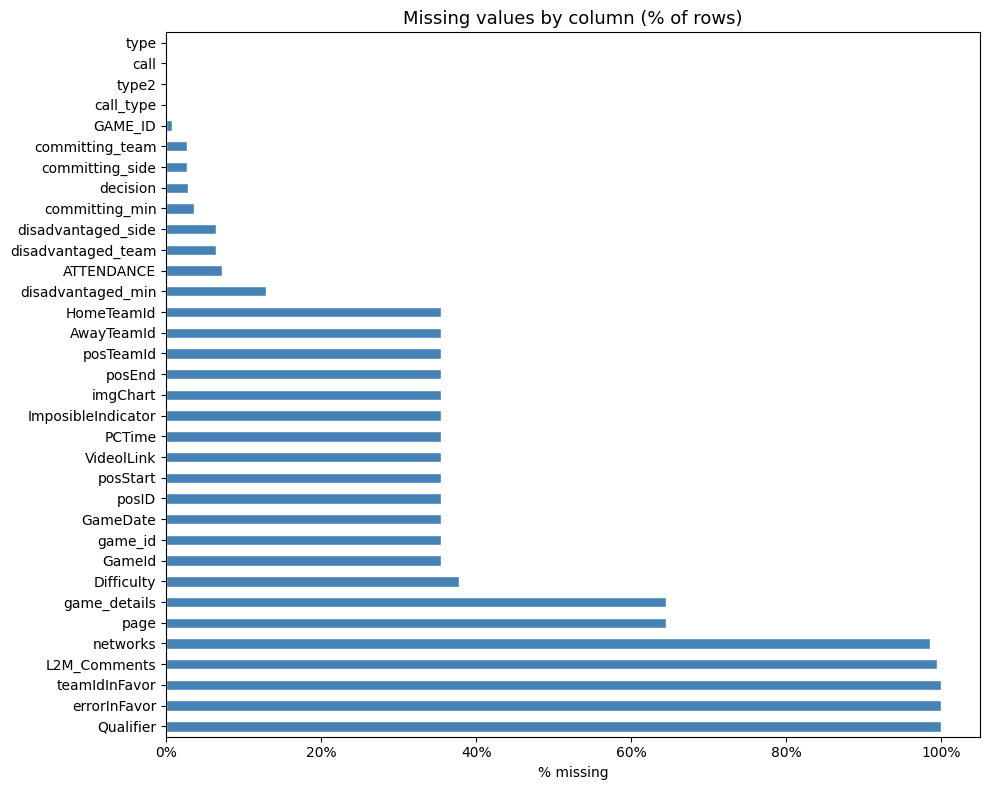

Columns with missing values: 34 / 53


In [7]:
# Missing values by column
missing = nba_data.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 8))
missing.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Missing values by column (% of rows)', fontsize=13)
ax.set_xlabel('% missing')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

print(f"Columns with missing values: {len(missing)} / {len(nba_data.columns)}")

**Missing Values** --- Missing values are identified across all columns and fall into three categories.

* **Expected and structural:** `game_details` and `page` have 58,270 missing values each --- absent for all API-sourced games. `Qualifier`, `teamIdInFavor`, `errorInFavor`, `L2M_Comments`, and `networks` are largely or entirely missing and are not used in the analysis. `game_id`, `PCTime`, `ImposibleIndicator`, `VideolLink`, `posID`, `posStart`, `posEnd`, `posTeamId`, `imgChart`, `GameId`, `GameDate`, `HomeTeamId`, and `AwayTeamId` have exactly 32,032 missing values each --- corresponding to PDF-sourced games for which the API data is not available.

* **Require attention:** `decision` has 2,502 missing values representing plays not detectable without technology, excluded from analysis following Pelechrinis (2023) [PelechrinisL2M]. `committing_side` and `committing_team` have 2,433 missing values each, while `disadvantaged_side` and `disadvantaged_team` have 5,801 --- these are critical for $\beta$ and $\delta$ calculations and are examined in the Tidy Data Preparation section. `ATTENDANCE` has 6,509 missing values. `GAME_ID` has 631 missing values.

* **Known data quality issues:** `call_type`, `call`, `type`, and `type2` share 48 missing values --- the same rows. `committing_min` has 3,183 missing values and `disadvantaged_min` has 11,681, partly due to NBA input errors [AtlhawksfanaticL2M]. The treatment of all remaining missing values is deferred to the Tidy Data Preparation section.

##### Duplicates

Duplicate rows are identified to assess data integrity.

In [8]:
print(f"Duplicate rows: {nba_data.duplicated().sum()}")
print(f"Total rows: {len(nba_data)}")

Duplicate rows: 58
Total rows: 90302


> **Duplicates** --- The dataset contains 58 duplicate rows out of 90,302, corresponding to less than $0.1\%$ of the data. These are examined at the raw dataset level only. After column selection in the Tidy Data Preparation section, additional duplicates may emerge as a result of dropping identifying columns --- this will be re-examined after tidying.

The categorical fields in the betting dataset are inspected to confirm structural consistency and identify any formatting issues prior to merging with the L2M dataset.

In [9]:
# Cardinality check for all columns
print("=== Cardinality Analysis ===")
print(f"{'Field':<30} {'Unique':>8}  {'Type':<10}  Sample values")
print("-" * 80)
for col in sorted(nba_data.columns):
    n = nba_data[col].nunique()
    dtype = str(nba_data[col].dtype)
    vals = nba_data[col].dropna().unique()
    sample = sorted([str(v) for v in vals if str(v) != 'nan'])[:4]
    print(f"  {col:<28} {n:>6}  {dtype:<10}  {sample}")

=== Cardinality Analysis ===
Field                            Unique  Type        Sample values
--------------------------------------------------------------------------------
  ATTENDANCE                     2175  float64     ['0.0', '1000.0', '10079.0', '1008.0']
  AwayTeamId                       30  float64     ['1610612737.0', '1610612738.0', '1610612739.0', '1610612740.0']
  Difficulty                        5  object      ['Blatant/Hard', 'Difficult', 'Observable', 'Technical']
  GAME_ID                        4454  float64     ['12000007.0', '12100023.0', '21400880.0', '21400883.0']
  GameDate                       2101  object      ['2019-01-01T00:00:00', '2019-01-02T00:00:00', '2019-01-03T00:00:00', '2019-01-04T00:00:00']
  GameId                         2810  float64     ['12000007.0', '12100023.0', '21800552.0', '21800561.0']
  HomeTeamId                       30  float64     ['1610612737.0', '1610612738.0', '1610612739.0', '1610612740.0']
  ImposibleIndicator             

> **Cardinality Analysis**
>
> **Core analytical fields** — `decision` contains exactly 4 values (CC, CNC, IC, INC) with no formatting inconsistencies, ensuring exact NWG aggregation. `committing_side` and `disadvantaged_side` are strictly binary (home/away), confirming a clean Home vs Away model.
>
> **Game identification fields** — `playoff` is strictly binary, `season` covers exactly 11 seasons (2015–2025), and `gid` has 4,487 unique values consistent with the expected number of close games.
>
> **Temporal fields** — `period` contains 5 values (Q4–Q7): Q4 is the standard final regulation period while Q5–Q7 represent overtime periods, capturing the highest-intensity game conclusions where structural convergence is most likely to occur.
>
> **Empty and zero-variance fields** — `Qualifier`, `teamIdInFavor`, and `errorInFavor` have zero unique values, justifying manual NWG calculation via `decision` and `side` rather than relying on missing pre-computed columns. `ImposibleIndicator` has a single value (0.0) and is excluded as a zero-variance field.

#### 4.1.3 Column-Level Analysis

The dataset contains 53 columns after removal of personal identifiers. Based on the source documentation [AtlhawksfanaticL2M] and the research questions defined in Section 3, a subset of columns is identified as candidates for analysis. The following sections examine each column group in detail, with the goal of determining which columns are suitable for inclusion in the final analytical dataset.

Column redundancy is assessed using the chi-squared test of independence for categorical columns and exact match rate where two columns represent the same value in different formats. Coverage analysis (% non-null) identifies structurally incomplete columns. A statistically significant chi-squared result indicates that two columns are associated — the stronger the association, the more redundant the columns are.

In [10]:
print(sorted(nba_data.columns.tolist(), key=str.lower))

['ATTENDANCE', 'away', 'away_score', 'away_team', 'AwayTeamId', 'call', 'call_type', 'committing_min', 'committing_side', 'committing_team', 'date', 'decision', 'Difficulty', 'disadvantaged_min', 'disadvantaged_side', 'disadvantaged_team', 'errorInFavor', 'file', 'game_date', 'game_details', 'game_id', 'GAME_ID', 'GameDate', 'GameId', 'gcode', 'gid', 'home', 'home_score', 'home_team', 'HomeTeamId', 'imgChart', 'ImposibleIndicator', 'L2M_Comments', 'national_tv', 'networks', 'page', 'PCTime', 'period', 'playoff', 'posEnd', 'posID', 'posStart', 'posTeamId', 'Qualifier', 'season', 'teamIdInFavor', 'time', 'time2', 'time_min', 'time_sec', 'type', 'type2', 'VideolLink']


From the sorted column list, several groups of similarly named columns are identified, suggesting redundancy or complementary representations of the same concept.

In [11]:
from collections import defaultdict

groups = defaultdict(list)
for col in nba_data.columns:
    prefix = col.lower().split('_')[0]
    groups[prefix].append(col)

for prefix, cols in sorted(groups.items()):
    if len(cols) > 1:
        print(f"{prefix}: {cols}")

# find the columns that are not in any group
grouped_cols = set()
for cols in groups.values():
    if len(cols) > 1:
        grouped_cols.update(cols)

ungrouped = [col for col in nba_data.columns if col not in grouped_cols]
print("Ungrouped columns:")
print(ungrouped)

away: ['away_team', 'away', 'away_score']
call: ['call_type', 'call']
committing: ['committing_min', 'committing_team', 'committing_side']
disadvantaged: ['disadvantaged_min', 'disadvantaged_team', 'disadvantaged_side']
game: ['game_details', 'game_date', 'game_id', 'GAME_ID']
home: ['home_team', 'home', 'home_score']
time: ['time', 'time_min', 'time_sec']
Ungrouped columns:
['period', 'decision', 'page', 'file', 'date', 'type', 'gid', 'gcode', 'national_tv', 'networks', 'PCTime', 'ImposibleIndicator', 'Difficulty', 'VideolLink', 'Qualifier', 'posID', 'posStart', 'posEnd', 'posTeamId', 'teamIdInFavor', 'errorInFavor', 'imgChart', 'GameId', 'GameDate', 'HomeTeamId', 'AwayTeamId', 'L2M_Comments', 'season', 'playoff', 'ATTENDANCE', 'type2', 'time2']


* **Game ID group**: `gid`, `game_id`, `GAME_ID`, `GameId`, `gcode` — four game identifier columns from different sources.

GAME_ID: NBA API game ID, same as gid  
game_id: nba.com url for L2M game, last part of “https://official.nba.com/l2m/L2MReport.html/”, not applicable for PDFs  
GameId: from official API  
gcode: NBA game code  
gid: NBA game ID  

In [12]:
print(nba_data[['gid', 'GAME_ID', 'game_id', 'GameId', 'gcode']].drop_duplicates().head(5))

games = nba_data.drop_duplicates(subset='gid').copy()
print(f"Total games: {len(games)}")
print(f"gid missing: {games['gid'].isnull().sum()}")
print(f"GAME_ID missing: {games['GAME_ID'].isnull().sum()}")
print(f"game_id missing: {games['game_id'].isnull().sum()}")
print(f"GameId missing: {games['GameId'].isnull().sum()}")
print(f"gcode missing: {games['gcode'].isnull().sum()}")

match = (games['gid'] == games['GAME_ID']).sum()
total = games['GAME_ID'].notna().sum()
print(f"\ngid vs GAME_ID match (per game): {match} / {total}")

         gid     GAME_ID  game_id  GameId            gcode
0   21400883  21400883.0      NaN     NaN  20150301/CLEHOU
21  21400880  21400880.0      NaN     NaN  20150301/GSWBOS
30  21400884  21400884.0      NaN     NaN  20150301/NOPDEN
43  21400886  21400886.0      NaN     NaN  20150302/GSWBKN
51  21400888  21400888.0      NaN     NaN  20150302/LACMIN
Total games: 4487
gid missing: 0
GAME_ID missing: 33
game_id missing: 1677
GameId missing: 1677
gcode missing: 0

gid vs GAME_ID match (per game): 4454 / 4454


> **Game ID group** --- Five game identifier columns exist: `gid`, `GAME_ID`, `game_id`, `GameId`, and `gcode`. At the game level ($4{,}487$ unique games), `gid` and `gcode` have complete coverage. `GAME_ID` has 33 missing values. `game_id` and `GameId` have $1{,}677$ missing values each. `gid` matches `GAME_ID` exactly across all $4{,}454$ non-missing cases. **The `gid` column is used as the primary game identifier throughout the analysis.**

* **Date group**: `date`, `game_date`, `GameDate` — three representations of the game date from different pipeline sources. 

In [13]:
print("Missing values (per game):")
print(f"date: {games['date'].isnull().sum()}")
print(f"game_date: {games['game_date'].isnull().sum()}")
print(f"GameDate: {games['GameDate'].isnull().sum()}")

print("\nData types:")
print(f"date: {games['date'].dtype}")
print(f"game_date: {games['game_date'].dtype}")
print(f"GameDate: {games['GameDate'].dtype}")

print("\nSample values:")
print(games[['date', 'game_date', 'GameDate']].head(5))

print("\nMatch date vs game_date:")
games['date_parsed'] = pd.to_datetime(games['date'])
games['game_date_parsed'] = pd.to_datetime(games['game_date'], format='mixed')
match = (games['date_parsed'] == games['game_date_parsed']).sum()
print(f"Matching: {match} / {games['game_date'].notna().sum()}")

Missing values (per game):
date: 0
game_date: 0
GameDate: 1677

Data types:
date: object
game_date: object
GameDate: object

Sample values:
          date     game_date GameDate
0   2015-03-01  Mar 01, 2015      NaN
21  2015-03-01  Mar 01, 2015      NaN
30  2015-03-01  Mar 01, 2015      NaN
43  2015-03-02  Mar 02, 2015      NaN
51  2015-03-02  Mar 02, 2015      NaN

Match date vs game_date:
Matching: 4487 / 4487


> **Date group** --- Three date columns exist: `date`, `game_date`, and `GameDate`. At the game level, `date` and `game_date` have complete coverage (0 missing), while `GameDate` has $1{,}677$ missing values corresponding to PDF-sourced games. All three columns are stored as `object` (string). `date` uses ISO format (YYYY-MM-DD), `game_date` uses a human-readable format (Mar 01, 2015), and `GameDate` uses datetime with time component from the official API. `date` and `game_date` are confirmed to represent identical values across all $4{,}487$ games. **The `date` column is selected for analysis as it has complete coverage and ISO format which is directly compatible with datetime conversion and betting data merge.**

* **Time group**: `time`, `time_min`, `time_sec`, `time2`, `PCTime` --- five representations of time remaining in the period, from raw string to parsed numeric values. `time`: time remaining in the period when play occurred. `time_min`: minutes remaining in period. `time_sec`: seconds remaining in period. `time2`: fractional minutes left (e.g., 1.9 would be one minute and 54 seconds).

In [14]:
# Time group — five representations of time remaining
print("Data types:")
for col in ['time', 'time_min', 'time_sec', 'time2', 'PCTime']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['time', 'time_min', 'time_sec', 'time2', 'PCTime']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['time', 'time_min', 'time_sec', 'time2', 'PCTime']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test vs time:")
for col in ['time_min', 'time_sec', 'time2']:
    subset = nba_data[['time', col]].dropna()
    ct = pd.crosstab(subset['time'], subset[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  time vs {col}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nChi-squared test time vs PCTime (where both non-null):")
subset = nba_data[['time', 'PCTime']].dropna()
ct = pd.crosstab(subset['time'], subset['PCTime'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"  time vs PCTime: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample values:")
print(nba_data[['time', 'time_min', 'time_sec', 'time2', 'PCTime']].head(5))

Data types:
  time: object
  time_min: int64
  time_sec: float64
  time2: float64
  PCTime: object

Coverage per column:
  time: 90302 / 90302 (100.0%)
  time_min: 90302 / 90302 (100.0%)
  time_sec: 90302 / 90302 (100.0%)
  time2: 90302 / 90302 (100.0%)
  PCTime: 58270 / 90302 (64.5%)

Unique values:
  time: 1515
  time_min: 8
  time_sec: 600
  time2: 1394
  PCTime: 1339

Chi-squared test vs time:
  time vs time_min: chi2=632114.0, p=0.00e+00, dof=10598
  time vs time_sec: chi2=54090898.0, p=0.00e+00, dof=906886
  time vs time2: chi2=125790686.0, p=0.00e+00, dof=2109002

Chi-squared test time vs PCTime (where both non-null):
  time vs PCTime: chi2=77965260.0, p=0.00e+00, dof=1790244

Sample values:
      time  time_min  time_sec     time2 PCTime
0  01:52.0         1      52.0  1.866667    NaN
1  01:43.0         1      43.0  1.716667    NaN
2  01:32.0         1      32.0  1.533333    NaN
3  01:09.0         1       9.0  1.150000    NaN
4  00:53.0         0      53.0  0.883333    NaN


> **Time group** --- The time group contains five columns representing time remaining in the period. `time` (object), `time_min` (int64), `time_sec` (float64), and `time2` (float64) all have complete coverage (100%). Chi-squared tests confirm significant association between `time` and all other columns ($p < 0.001$ in all cases) --- all four are redundant representations of the same value at different levels of precision (8, 600, and 1,394 unique values respectively). `PCTime` (object) has 64.5% coverage --- absent for all PDF-sourced games --- and is significantly associated with `time` where both non-null ($p < 0.001$). `PCTime` is dropped as structurally incomplete and redundant with `time`. The remaining four columns are retained in the raw data for potential future temporal analysis.

The maximum value of `time_min` is 12, which is unexpected --- L2M reports should only cover the last two minutes of each period. These rows are investigated below.

In [15]:
print(nba_data['time_min'].describe())

count    90302.000000
mean         0.435029
std          0.575313
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         12.000000
Name: time_min, dtype: float64


In [16]:
print(nba_data[nba_data['time_min'] > 2][['period', 'time', 'time_min', 'season', 'decision']].head(10))

    period     time  time_min  season decision
6       Q5  04:34.0         4    2015       CC
7       Q5  04:34.0         4    2015       CC
8       Q5  04:05.0         4    2015      CNC
9       Q5  03:54.0         3    2015      INC
134     Q5  04:50.0         4    2015      CNC
135     Q5  04:42.0         4    2015       CC
136     Q5  04:26.0         4    2015      CNC
137     Q5  04:02.0         4    2015       CC
138     Q5  03:43.0         3    2015       CC
139     Q5  03:41.0         3    2015      CNC


> **time_min range** --- Rows with `time_min > 2` are exclusively from overtime periods (Q5) in the 2015 season, where the full 5-minute overtime period was graded rather than only the last two minutes. This is a known inconsistency in early L2M reporting [AtlhawksfanaticL2M]. These rows are retained in the analysis --- excluding them would disproportionately reduce the already smallest season in the dataset (2015).

* **Call group**: `call_type`, `call`, `type`, `type2` --- `call_type` is the full description, `call` is the first component before the colon, `type` is the second component after the colon, and `type2` is a standardized version of `type`.

In [17]:
# Call group — four columns representing the same infraction at different granularity levels
call_cols = ['call_type', 'call', 'type', 'type2']

print("Coverage per column:")
for col in call_cols:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values per column:")
for col in call_cols:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test vs call_type:")
for col in ['call', 'type', 'type2']:
    subset = nba_data[['call_type', col]].dropna()
    ct = pd.crosstab(subset['call_type'], subset[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  call_type vs {col}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample values:")
print(nba_data[call_cols].head(5))

Coverage per column:
  call_type: 90254 / 90302 (99.9%)
  call: 90254 / 90302 (99.9%)
  type: 90254 / 90302 (99.9%)
  type2: 90254 / 90302 (99.9%)

Unique values per column:
  call_type: 74
  call: 7
  type: 72
  type2: 53

Chi-squared test vs call_type:
  call_type vs call: chi2=541524.0, p=0.00e+00, dof=438
  call_type vs type: chi2=6408034.0, p=0.00e+00, dof=5183
  call_type vs type2: chi2=4693208.0, p=0.00e+00, dof=3796

Sample values:
          call_type  call        type       type2
0    Foul: Shooting  FOUL    SHOOTING    SHOOTING
1    Foul: Shooting  FOUL    SHOOTING    SHOOTING
2    Foul: Shooting  FOUL    SHOOTING    SHOOTING
3  Foul: Loose Ball  FOUL  LOOSE BALL  LOOSE BALL
4    Foul: Shooting  FOUL    SHOOTING    SHOOTING


> **Call group** --- The call group contains four columns representing the same infraction at different levels of granularity. All four have identical coverage (99.9%, 48 missing). `call_type` is the most granular (74 unique values, e.g. `Foul: Shooting`), `call` is the highest-level category (7 unique values, e.g. `FOUL`), and `type` and `type2` are intermediate representations (72 and 53 unique values respectively). Chi-squared tests confirm significant association between `call_type` and all three columns ($p < 0.001$ in all cases). `call`, `type`, and `type2` are dropped. `call_type` is retained as it provides the finest granularity required for the Monte Carlo simulation, where error probabilities are estimated separately per call type.

The distribution of `call` and `call_type` is examined to understand the composition of graded plays.

In [18]:
print("\nSample values:")
print(nba_data[call_cols].head(5))
print("\nUnique values call:")
total = nba_data['call'].notna().sum()
vc = nba_data['call'].value_counts()
print(pd.DataFrame({'count': vc, 'pct': vc/total*100}).round(1))
print("\nUnique values call_type (top 10):")
total = nba_data['call_type'].notna().sum()
vc = nba_data['call_type'].value_counts().head(10)
print(pd.DataFrame({'count': vc, 'pct': vc/total*100}).round(1))


Sample values:
          call_type  call        type       type2
0    Foul: Shooting  FOUL    SHOOTING    SHOOTING
1    Foul: Shooting  FOUL    SHOOTING    SHOOTING
2    Foul: Shooting  FOUL    SHOOTING    SHOOTING
3  Foul: Loose Ball  FOUL  LOOSE BALL  LOOSE BALL
4    Foul: Shooting  FOUL    SHOOTING    SHOOTING

Unique values call:
                      count   pct
call                             
FOUL                  79158  87.7
TURNOVER               7383   8.2
STOPPAGE               1296   1.4
INSTANT REPLAY         1219   1.4
VIOLATION              1190   1.3
EJECTION                  4   0.0
FREE THROW TECHNICAL      4   0.0

Unique values call_type (top 10):
                                count   pct
call_type                                  
Foul: Personal                  27223  30.2
Foul: Shooting                  23121  25.6
Foul: Offensive                 17318  19.2
Foul: Loose Ball                 8303   9.2
Turnover: Traveling              3224   3.6
Foul: Defense 

> `call` provides a higher-level categorization with 7 unique values (FOUL: 87.7%, TURNOVER: 8.2%, STOPPAGE: 1.4%, INSTANT REPLAY: 1.4%, VIOLATION: 1.3%, EJECTION and FREE THROW TECHNICAL: $<0.1\%$ each). `type` and `type2` are intermediate representations (72 and 53 unique values respectively), derived from `call_type` and sharing the same 48 missing values. `call_type` is retained as the most granular representation. The distribution of violation types is examined below.

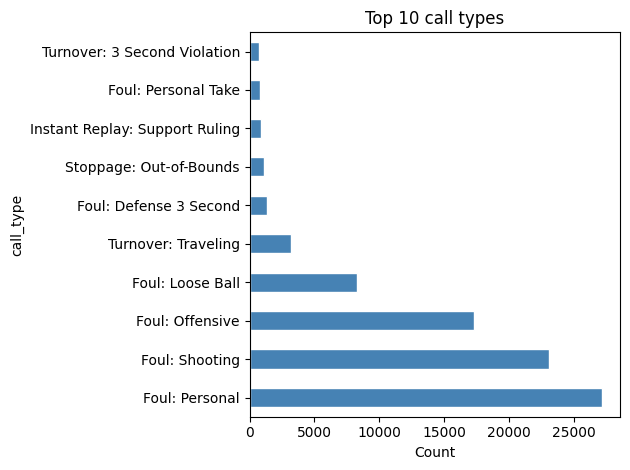

In [19]:
nba_data['call_type'].value_counts().head(10).plot(
    kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 call types')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

* **Home group**: `home`, `home_team`, `HomeTeamId`, `home_score` — abbreviation, nickname, and API identifier for the home team.
home: home team abbreviation  
home_score: home final score from the L2M reports, incomplete variable  
home_team: home team nickname  

In [20]:
# Home group — abbreviation, full nickname, score and API identifier
print("Data types:")
for col in ['home', 'home_team', 'home_score', 'HomeTeamId']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['home', 'home_team', 'home_score', 'HomeTeamId']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['home', 'home_team', 'home_score', 'HomeTeamId']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test:")
for pair in [('home', 'home_team'), ('home', 'HomeTeamId')]:
    subset = nba_data[[pair[0], pair[1]]].dropna()
    ct = pd.crosstab(subset[pair[0]], subset[pair[1]])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  {pair[0]} vs {pair[1]}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample mapping:")
print(nba_data[['home', 'home_team', 'HomeTeamId']].drop_duplicates().sort_values('home').head(10))

Data types:
  home: object
  home_team: object
  home_score: int64
  HomeTeamId: float64

Coverage per column:
  home: 90302 / 90302 (100.0%)
  home_team: 90302 / 90302 (100.0%)
  home_score: 90302 / 90302 (100.0%)
  HomeTeamId: 58270 / 90302 (64.5%)

Unique values:
  home: 30
  home_team: 30
  home_score: 81
  HomeTeamId: 30

Chi-squared test:
  home vs home_team: chi2=2618758.0, p=0.00e+00, dof=841
  home vs HomeTeamId: chi2=1689830.0, p=0.00e+00, dof=841

Sample mapping:
      home home_team    HomeTeamId
34000  ATL     Hawks  1.610613e+09
66     ATL     Hawks           NaN
33003  BKN      Nets  1.610613e+09
43     BKN      Nets           NaN
32723  BOS   Celtics  1.610613e+09
21     BOS   Celtics           NaN
77     CHA   Hornets           NaN
33556  CHA   Hornets  1.610613e+09
88     CHI     Bulls           NaN
31955  CHI     Bulls  1.610613e+09


> **Home group** --- The home group contains four columns. `home` (object) and `home_team` (object) both have complete coverage (100%) and are significantly associated ($\chi^2 = 2{,}618{,}758$, $p < 0.001$) --- one is fully determined by the other. `HomeTeamId` (float64) is the NBA API numeric identifier with 32,032 missing values (35.5%) corresponding to PDF-sourced games, but is significantly associated with `home` where non-missing ($\chi^2 = 1{,}689{,}830$, $p < 0.001$). `home_score` (int64) has complete coverage (100%) and 81 unique values --- not redundant with the identifier columns and retained for in-game context analysis. `home` is retained as the primary team identifier (abbreviation format) for merging with the betting dataset. `home_team` is retained as an auxiliary identifier. `HomeTeamId` is dropped --- structurally incomplete and redundant with `home`.

* **Away group**: `away`, `away_team`, `AwayTeamId` — same structure for the away team.  
away: away team abbreviation  
away_score: away final score from the L2M reports, incomplete variable  
away_team: away team nickname  
AwayTeamId: from official API  


In [21]:
# Away group — abbreviation, full nickname, score and API identifier
print("Data types:")
for col in ['away', 'away_team', 'away_score', 'AwayTeamId']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['away', 'away_team', 'away_score', 'AwayTeamId']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['away', 'away_team', 'away_score', 'AwayTeamId']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test:")
for pair in [('away', 'away_team'), ('away', 'AwayTeamId')]:
    subset = nba_data[[pair[0], pair[1]]].dropna()
    ct = pd.crosstab(subset[pair[0]], subset[pair[1]])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  {pair[0]} vs {pair[1]}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample mapping:")
print(nba_data[['away', 'away_team', 'AwayTeamId']].drop_duplicates().sort_values('away').head(10))

Data types:
  away: object
  away_team: object
  away_score: int64
  AwayTeamId: float64

Coverage per column:
  away: 90302 / 90302 (100.0%)
  away_team: 90302 / 90302 (100.0%)
  away_score: 90302 / 90302 (100.0%)
  AwayTeamId: 58270 / 90302 (64.5%)

Unique values:
  away: 30
  away_team: 30
  away_score: 79
  AwayTeamId: 30

Chi-squared test:
  away vs away_team: chi2=2618758.0, p=0.00e+00, dof=841
  away vs AwayTeamId: chi2=1689830.0, p=0.00e+00, dof=841

Sample mapping:
      away away_team    AwayTeamId
32120  ATL     Hawks  1.610613e+09
230    ATL     Hawks           NaN
32622  BKN      Nets  1.610613e+09
788    BKN      Nets           NaN
32322  BOS   Celtics  1.610613e+09
863    BOS   Celtics           NaN
875    CHA   Hornets           NaN
32099  CHA   Hornets  1.610613e+09
310    CHI     Bulls           NaN
34229  CHI     Bulls  1.610613e+09


> **Away group** --- The away group mirrors the home group exactly. `away` (object) and `away_team` (object) both have complete coverage (100%) and are significantly associated ($\chi^2 = 2{,}618{,}758$, $p < 0.001$). `AwayTeamId` (float64) has 32,032 missing values (35.5%) --- absent for PDF-sourced games --- and is significantly associated with `away` where non-missing ($\chi^2 = 1{,}689{,}830$, $p < 0.001$). `away_score` (int64) has complete coverage and 79 unique values --- retained for in-game context analysis. `away` is retained as the primary team identifier (abbreviation format) for merging with the betting dataset. `away_team` is retained as an auxiliary identifier. `AwayTeamId` is dropped --- structurally incomplete and redundant with `away`.

* **Committing group**: `committing_min`, `committing_team`, `committing_side` — attributes of the player committing the infraction.  
committing: committing player or team of the graded infraction in L2M, may be blank  
committing_min: total minutes played by player committing action (note, may be NA because the player did not play and likely an input error from NBA on L2M)  
committing_side: home/away for committing player  
committing_team: team for committing player  

In [22]:
# Committing group
print("Data types:")
for col in ['committing_team', 'committing_side', 'committing_min']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['committing_team', 'committing_side', 'committing_min']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['committing_team', 'committing_side', 'committing_min']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test:")
subset = nba_data[['committing_team', 'committing_side']].dropna()
ct = pd.crosstab(subset['committing_team'], subset['committing_side'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"  committing_team vs committing_side: chi2={chi2:.1f}, p={p:.4f}, dof={dof}")

print("\nSample:")
print(nba_data[['committing_team', 'committing_side', 'home_team']].dropna().head(10))

Data types:
  committing_team: object
  committing_side: object
  committing_min: float64

Coverage per column:
  committing_team: 87869 / 90302 (97.3%)
  committing_side: 87869 / 90302 (97.3%)
  committing_min: 87119 / 90302 (96.5%)

Unique values:
  committing_team: 30
  committing_side: 2
  committing_min: 2536

Chi-squared test:
  committing_team vs committing_side: chi2=224.4, p=0.0000, dof=29

Sample:
   committing_team committing_side home_team
0              HOU            home   Rockets
1              CLE            away   Rockets
2              HOU            home   Rockets
3              HOU            home   Rockets
4              CLE            away   Rockets
5              HOU            home   Rockets
6              CLE            away   Rockets
8              CLE            away   Rockets
9              CLE            away   Rockets
10             HOU            home   Rockets


> **Committing group** --- The committing group contains three columns. `committing_team` (object) and `committing_side` (object) have identical coverage (97.3%, 2,433 missing). Chi-squared test shows a statistically significant but weak association ($\chi^2 = 224.4$, $p < 0.001$, $dof = 29$) --- they are not redundant. `committing_team` identifies the specific franchise while `committing_side` encodes the relative position (home/away) which changes with each game. `committing_min` (float64) records minutes played by the committing player (96.5% coverage) and is dropped. `committing_team` is retained for potential team-level analysis. `committing_side` is retained as the core variable for $\beta$ and $\delta$ calculation. The treatment of 2,433 missing values is deferred.

In [23]:
print('Unique values:')
print(nba_data['committing_side'].unique())
print()
print('Missing:', nba_data['committing_side'].isnull().sum())
print()
print(nba_data['committing_side'].value_counts(dropna=False))

Unique values:
['home' 'away' nan]

Missing: 2433

committing_side
away    44183
home    43686
NaN      2433
Name: count, dtype: int64


> **committing_side distribution** --- The `committing_side` column identifies whether the player committing the infraction belongs to the home or away team. Together with `decision`, it is the core column for calculating $\beta$ and $\delta$ as defined in Section 3.3. The column takes two clean values: `home` and `away`, with 2,433 missing values (2.7%). The distribution is nearly balanced --- 44,183 away (49.9%) and 43,686 home (49.4%) --- which is expected as there is no a priori reason for one side to commit more infractions. Missing values will be examined in the Tidy Data Preparation section.

* **Disadvantaged group**: `disadvantaged_min`, `disadvantaged_team`, `disadvantaged_side` — attributes of the player disadvantaged by the infraction.  
disadvantaged_min: total minutes played by player disadvantaged by action  
disadvantaged_side: home/away for disadvantaged player  
disadvantaged_team: team for disadvantaged player  

In [24]:
# Disadvantaged group
print("Data types:")
for col in ['disadvantaged_team', 'disadvantaged_side', 'disadvantaged_min']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['disadvantaged_team', 'disadvantaged_side', 'disadvantaged_min']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['disadvantaged_team', 'disadvantaged_side', 'disadvantaged_min']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test:")
subset = nba_data[['disadvantaged_team', 'disadvantaged_side']].dropna()
ct = pd.crosstab(subset['disadvantaged_team'], subset['disadvantaged_side'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"  disadvantaged_team vs disadvantaged_side: chi2={chi2:.1f}, p={p:.4f}, dof={dof}")

print("\nSample:")
print(nba_data[['disadvantaged_team', 'disadvantaged_side', 'home_team']].dropna().head(10))

Data types:
  disadvantaged_team: object
  disadvantaged_side: object
  disadvantaged_min: float64

Coverage per column:
  disadvantaged_team: 84501 / 90302 (93.6%)
  disadvantaged_side: 84501 / 90302 (93.6%)
  disadvantaged_min: 78621 / 90302 (87.1%)

Unique values:
  disadvantaged_team: 30
  disadvantaged_side: 2
  disadvantaged_min: 2426

Chi-squared test:
  disadvantaged_team vs disadvantaged_side: chi2=224.4, p=0.0000, dof=29

Sample:
   disadvantaged_team disadvantaged_side home_team
0                 CLE               away   Rockets
1                 HOU               home   Rockets
2                 CLE               away   Rockets
3                 CLE               away   Rockets
4                 HOU               home   Rockets
5                 CLE               away   Rockets
6                 HOU               home   Rockets
8                 HOU               home   Rockets
9                 HOU               home   Rockets
10                CLE               away   Roc

> **Disadvantaged group** --- The disadvantaged group mirrors the committing group structurally. `disadvantaged_team` (object) and `disadvantaged_side` (object) have identical coverage (93.6%, 5,801 missing --- notably more than committing, 2,433). Chi-squared test shows a statistically significant but weak association ($\chi^2 = 224.4$, $p < 0.001$, $dof = 29$) --- they are not redundant. `disadvantaged_team` identifies the specific franchise while `disadvantaged_side` encodes the relative position (home/away). `disadvantaged_min` (float64) records minutes played by the disadvantaged player (87.1% coverage) and is dropped. `disadvantaged_team` is retained for potential team-level analysis. `disadvantaged_side` is retained as a core variable for $\beta$ and $\delta$ calculation. The treatment of 5,801 missing values is deferred.

In [25]:
print('Unique values:')
print(nba_data['disadvantaged_side'].unique())
print()
print('Missing:', nba_data['disadvantaged_side'].isnull().sum())
print()
print(nba_data['disadvantaged_side'].value_counts(dropna=False))

Unique values:
['away' 'home' nan]

Missing: 5801

disadvantaged_side
home    42428
away    42073
NaN      5801
Name: count, dtype: int64


> **Disadvantaged group** --- The disadvantaged group mirrors the committing group structurally. `disadvantaged_team` (object) and `disadvantaged_side` (object) have identical coverage (93.6%, 5,801 missing --- notably more than committing, 2,433). Chi-squared test shows a statistically significant but weak association ($\chi^2 = 224.4$, $p < 0.001$, $dof = 29$) --- they are not redundant. `disadvantaged_team` identifies the specific franchise while `disadvantaged_side` encodes the relative position (home/away). `disadvantaged_min` (float64) records minutes played by the disadvantaged player (87.1% coverage) and is dropped. `disadvantaged_team` is retained for potential team-level analysis. `disadvantaged_side` is retained as a core variable for $\beta$ and $\delta$ calculation. The treatment of 5,801 missing values is deferred.

* **Decision column** --- the core variable of the analysis. The distribution of values is examined to understand the balance between correct and incorrect calls, and to confirm the presence of blank entries that will be excluded. `decision` takes four values: **CC** (Correct Call), **CNC** (Correct Non-Call), **IC** (Incorrect Call), and **INC** (Incorrect Non-Call).

In [26]:
print(nba_data['decision'].value_counts(dropna=False))

decision
CNC    60590
CC     21023
INC     5391
NaN     2502
IC       796
Name: count, dtype: int64


The key variable is `decision`, which takes four values: **CC** (Correct Call), **CN**C (Correct Non-Call), **IC** (Incorrect Call), and **INC** (Incorrect Non-Call). A fifth value — blank — indicates plays that were not detectable without technology and are excluded from analysis.

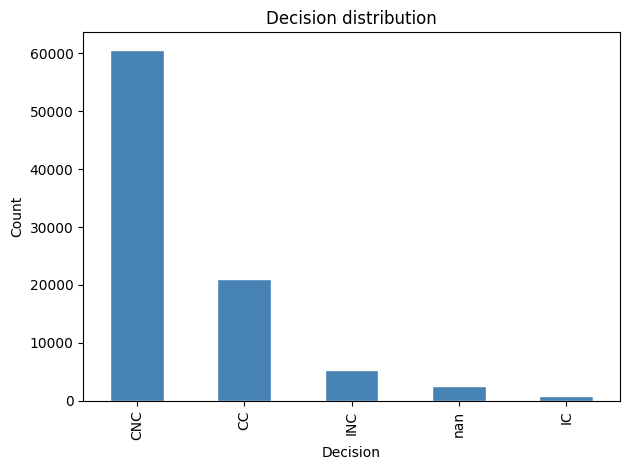

In [27]:
nba_data['decision'].value_counts(dropna=False).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Decision distribution')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The `decision` column is the core variable of the analysis. It takes four values: CC (Correct Call), CNC (Correct Non-Call), IC (Incorrect Call), and INC (Incorrect Non-Call). A fifth value — blank (NaN) — indicates plays not detectable without technology.

The distribution shows that CNC accounts for 60,590 entries (67.2% of all rows), followed by CC (21,023), INC (5,391), NaN (2,502), and IC (796). Pelechrinis (2023) notes that CNC criteria changed across seasons — during the 2015 season there were 6.4 CNC entries per game, while during the 2022 season there were almost 14 [PelechrinisL2M]. This inconsistency makes CNC unsuitable for longitudinal analysis. NaN entries are also excluded as they represent plays not detectable without technology. The working dataset therefore consists of CC (21,023), IC (796), and INC (5,391) — a total of 27,210 rows.

* **Season column** --- the distribution of rows by season is examined to confirm coverage and identify any gaps.

In [28]:
# Games per season
print(nba_data.groupby('season')['gid'].nunique())

season
2015    139
2016    439
2017    428
2018    475
2019    455
2020    395
2021    406
2022    442
2023    474
2024    411
2025    423
Name: gid, dtype: int64


2018 has more games (475) than 2019 (455), yet 2019 has more rows. This means the difference is not in the number of games — we check average actions per game to find the cause.

**Note** — the dataset contains 395–475 games per season, not 1,230. L2M reports are released only for close games (≤5 points in the last two minutes), which represents approximately 35–40% of all regular season games. A standard NBA season has 1,230 games (30 teams × 82 games / 2) [AtlhawksfanaticL2M].

In [29]:
# Rows per game by season
print(nba_data.groupby('season').apply(
    lambda x: len(x) / x['gid'].nunique(), include_groups=False
).round(1))

season
2015    14.2
2016    15.6
2017    17.6
2018    22.3
2019    25.1
2020    20.8
2021    19.5
2022    20.0
2023    24.3
2024    20.1
2025    16.9
dtype: float64


2019 peaks at 25.1 actions per game — the highest in the dataset. 2019 has more rows than 2018 despite fewer games (455 vs 475): the average actions per game in 2019 is 25.1 — the highest in the dataset — compared to the 2018 value shown above.

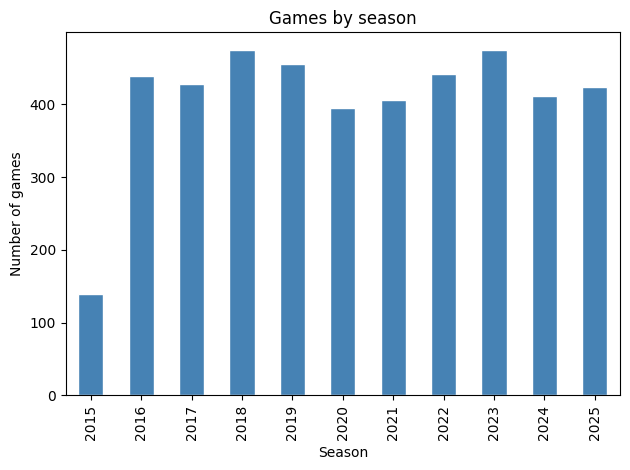

In [30]:
nba_data.groupby('season')['gid'].nunique().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Games by season')
plt.xlabel('Season')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

> **Observation** — 2015 has significantly fewer rows (1,972) and fewer games (139) as it was the first year of L2M reporting. Coverage stabilizes from 2016 onward. The drop in 2020–2022 reflects both fewer games (395–442 vs 455–475 in 2018–2019) and fewer graded actions per game (19.5–20.8 vs 25.1 in 2019). 2025 shows the lowest actions per game (16.9) because the season was still ongoing when the data was collected.

* **Playoff column** --- the split between regular season and playoff games is examined. Dummy variable equal to `True` if the game occurred in the playoffs.

In [31]:
games = nba_data.drop_duplicates(subset='gid')

print('Unique values:')
print(games['playoff'].unique())
print()
print('Missing:', games['playoff'].isnull().sum())
print()
print(games['playoff'].value_counts())
print(f'Total games: {len(games)}')

Unique values:
[False  True]

Missing: 0

playoff
False    4191
True      296
Name: count, dtype: int64
Total games: 4487


> **Playoff column** --- The `playoff` column is a boolean variable with no missing values. At the game level ($4{,}487$ unique games), 4,191 games (93.4%) are regular season and 296 games (6.6%) are playoff games. The column is used for period segmentation in the auxiliary hypothesis and will be converted to integer (0/1) if required by specific statistical procedures.

* **Attendance column** --- The range and distribution of values are examined, including games with zero attendance which correspond to the COVID bubble.

Unique values and missing --- the range of attendance values and missing entries are identified.

In [32]:
print('Unique values:')
print(nba_data['ATTENDANCE'].unique())
print()
print('Missing:', nba_data['ATTENDANCE'].isnull().sum())
print()
print(nba_data['ATTENDANCE'].value_counts(dropna=False))

Unique values:
[18345. 18624. 13109. ... 19734. 19932. 17561.]

Missing: 6509

ATTENDANCE
NaN        6509
18997.0    2345
19800.0    2119
19600.0    1968
19812.0    1752
           ... 
21749.0       4
18434.0       4
14629.0       4
17831.0       2
15393.0       1
Name: count, Length: 2176, dtype: int64


Distribution --- the attendance distribution is visualized to identify patterns and anomalies.

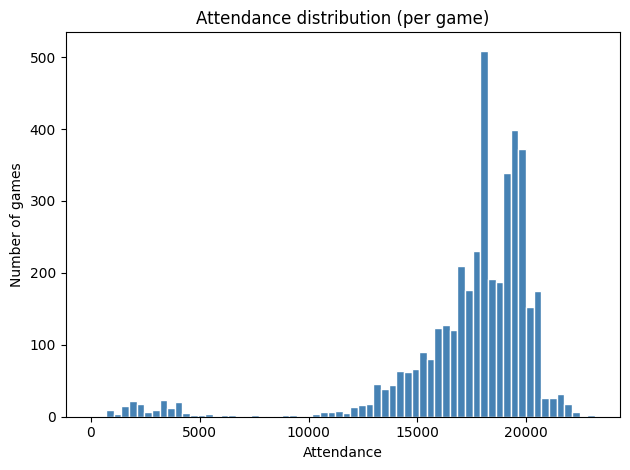

In [33]:
nba_data.drop_duplicates(subset='gid')['ATTENDANCE'].dropna().plot(
    kind='hist', bins='fd', color='steelblue', edgecolor='white')
plt.title('Attendance distribution (per game)')
plt.xlabel('Attendance')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

Low attendance investigation --- the histogram shows a small group below 5,000. The seasons these belong to are identified below.

In [34]:
print('Rows with ATTENDANCE < 5000:')
print(nba_data[nba_data['ATTENDANCE'] < 5000]['season'].value_counts().sort_index())

Rows with ATTENDANCE < 5000:
season
2021    2864
2022      13
Name: count, dtype: int64


Zero attendance appears only in 2022, not in 2020. The NBA 2020 season was completed in a controlled bubble environment in Orlando — all games were recorded under a single venue and attendance was uniformly zero, but the ATTENDANCE column records this as missing rather than zero for that period. The structural absence of fans in 2020 is therefore real, but is captured by the season variable rather than `ATTENDANCE`.

In [35]:
mask = (nba_data['ATTENDANCE'] < 5000) & (nba_data['season'] == 2022)
cols = ['gid', 'season', 'home_team', 'away_team', 'date', 'call_type', 'decision', 'ATTENDANCE']
print(f'Rows: {mask.sum()}, Unique games: {nba_data[mask]["gid"].nunique()}')
print(nba_data[mask][cols].to_string())

Rows: 13, Unique games: 1
            gid  season home_team away_team        date               call_type decision  ATTENDANCE
59965  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Personal      CNC         0.0
59966  22100850    2022   Raptors   Nuggets  2022-02-12         Foul: Offensive      CNC         0.0
59967  22100850    2022   Raptors   Nuggets  2022-02-12         Foul: Offensive      CNC         0.0
59968  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting      CNC         0.0
59969  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting       CC         0.0
59970  22100850    2022   Raptors   Nuggets  2022-02-12  Foul: Defense 3 Second      INC         0.0
59971  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting      CNC         0.0
59972  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Personal      CNC         0.0
59973  22100850    2022   Raptors   Nuggets  2022-02-12          

The single 2022 game with restricted attendance is confirmed and 13 rows are verified to correspond to one game.

In [36]:
games = nba_data.drop_duplicates(subset='gid')
print(games.groupby('home_team')['ATTENDANCE'].median().sort_values(ascending=False).head(15))

home_team
Bulls            21116.0
76ers            20319.5
Mavericks        20157.0
Knicks           19812.0
Raptors          19800.0
Heat             19600.0
Nuggets          19520.0
Cavaliers        19432.0
Trail Blazers    19393.0
Clippers         19060.0
Lakers           18997.0
Celtics          18624.0
Spurs            18354.0
Jazz             18306.0
Thunder          18203.0
Name: ATTENDANCE, dtype: float64


Тhe peaks in the attendance distribution reflect fixed arena capacities. Bulls lead with median 21,116, followed by 76ers (20,319) and Mavericks (20,157). This is expected — arenas have a maximum capacity which creates natural clustering. This does not affect our analysis.

In [37]:
def calc_entropy(series):
    counts = pd.cut(series, bins=20).value_counts()
    probs = counts / counts.sum()
    return stats.entropy(probs)

attendance_entropy = nba_data.drop_duplicates(subset='gid').groupby('season')['ATTENDANCE'].apply(
    lambda x: calc_entropy(x.dropna())
)

print(attendance_entropy)

season
2015    2.615408
2016    2.527409
2017    2.599285
2018    2.492446
2019    2.492698
2020    2.613304
2021    2.075035
2022    2.129570
2023    2.453236
2024    2.387664
2025    2.290795
Name: ATTENDANCE, dtype: float64


Pre-COVID seasons (2015–2020) show stable entropy between 2.49 and 2.61, reflecting the natural variation of normal game attendance. The COVID seasons (2021–2022) show a sharp drop to 2.07–2.13, consistent with restricted capacity games clustering around a narrow range of low values. Post-COVID seasons (2023–2025) show partial recovery to 2.29–2.45, but have not returned to Pre-COVID levels. 

The entropy pattern suggests that `ATTENDANCE` may be more appropriately treated as a categorical variable than a continuous one, as it reflects arena capacity constraints and a structural break during the COVID period. This will be considered in the Tidy Data Preparation section.

> **Observation** — The `ATTENDANCE` column records the number of fans present at each game. It has 6,509 missing values (7.2%). The distribution clusters between 13,000–23,000, reflecting fixed arena capacities. Bulls lead with a median of 21,116, followed by 76ers (20,319) and Mavericks (20,157). A secondary cluster of 2,877 rows falls below 5,000 — 2,864 from the 2021 season played with restricted crowd capacity due to the COVID-19 pandemic, and 13 rows from a single Raptors vs Nuggets game (February 12, 2022) played without fans due to local public health restrictions. When analyzing the relationship between attendance and referee bias, the low-attendance group must be treated separately or controlled for via the `season` variable.

* **national_tv**: national TV network for the game, "no" indicates none

In [38]:
print('Unique values (per game):')
print(games['national_tv'].value_counts(dropna=False))
print()
print('Missing:', games['national_tv'].isnull().sum())
print(f'Total games: {len(games)}')

Unique values (per game):
national_tv
no                              3235
ESPN                             358
NBA TV                           355
TNT                              308
ABC                              114
NBATV                             36
TNT/truTV/Max                     32
TNT/truTV                         17
TNT OT                             9
TNT/Max                            6
ABC/ESPN+                          4
ESPN/ESPN2                         3
ABC/ESPN/ESPN+/Disney+             3
ABC/ESPN                           3
ESPN & ABC Simulcast               1
ESPN2                              1
ESPN 2                             1
ABC/ESPN/ESPN2/ESPN+/Disney+       1
Name: count, dtype: int64

Missing: 0
Total games: 4487


> **national_tv** --- The `national_tv` column identifies the national broadcast network for each game. It is a per-game attribute repeated for every row within a game, so the analysis is performed at the game level ($4{,}487$ unique games). There are no missing values. The majority of games were not nationally broadcast (3,235 games, 72.1%). Among nationally broadcast games, ESPN (358), NBA TV (355), and TNT (308) are the most frequent networks, followed by ABC (114). The remaining values represent multi-network simulcasts and variants. For analysis, `national_tv` is treated as a binary variable: `1` if the game was broadcast on any national network, and `0` otherwise. This binary grouping captures 1,252 nationally broadcast games (27.9%) versus 3,235 non-nationally broadcast games (72.1%).

* **Period column** --- the distribution of game periods is examined.

In [39]:
print('Period distribution:')
print(nba_data['period'].value_counts())

Period distribution:
period
Q4    78374
Q5    10533
Q6     1189
Q7      129
Q8       77
Name: count, dtype: int64


> **Period column** --- The `period` column identifies the game period of each graded play. The majority of plays occur in Q4 ($78{,}374$, 86.8%). Overtime periods Q5 through Q8 account for $11{,}928$ rows (13.2%), distributed across Q5 ($10{,}533$), Q6 ($1{,}189$), Q7 ($129$), and Q8 ($77$). Overtime games are included in the analysis as they represent close game situations where crowd pressure and referee bias are equally relevant.

##### **Ungrouped Column** 

Several columns are excluded from further analysis. `page` and `file` are PDF pipeline artifacts absent for all API-sourced games. `gcode` and `networks` duplicate information already captured by `gid` and `national_tv` respectively. The remaining 16 API-sourced columns (`PCTime`, `posID`, `posStart`, `posEnd`, `posTeamId`, `teamIdInFavor`, `errorInFavor`, `imgChart`, `GameId`, `GameDate`, `HomeTeamId`, `AwayTeamId`, `L2M_Comments`, `ImposibleIndicator`, `Difficulty`, `VideolLink`, `Qualifier`) have 32,032 or more missing values and are not used in the analysis.

`page` and `file` are described in the source documentation as PDF pipeline artifacts. `page` records the page number within the PDF report, while `file` stores the filename — either a `.pdf` file for archived seasons or a `.csv` file for API-sourced games. We verify their missingness pattern and content to confirm they carry no analytical value.

In [40]:
print("=== page ===")
print(f"Missing: {nba_data['page'].isna().sum()} ({nba_data['page'].isna().mean():.1%})")
print(f"Sample: {nba_data['page'].dropna().head(3).tolist()}")

print("\n=== file ===")
print(f"Missing: {nba_data['file'].isna().sum()} ({nba_data['file'].isna().mean():.1%})")
print(f"Unique: {nba_data['file'].nunique()}")
print(f"Sample PDF: {nba_data[nba_data['file'].str.endswith('.pdf', na=False)]['file'].iloc[0]}")
print(f"Sample API: {nba_data[nba_data['file'].str.endswith('.csv', na=False)]['file'].iloc[0]}")

=== page ===
Missing: 58270 (64.5%)
Sample: [1.0, 1.0, 1.0]

=== file ===
Missing: 0 (0.0%)
Unique: 4488
Sample PDF: L2M-CLE-HOU-3-1-15.pdf
Sample API: 0021800552.csv


> **Observation** — `page` has 58,270 missing values (64.5%) — absent for all API-sourced games as page numbers are only relevant for PDF reports. It carries no analytical value and is dropped. `file` has complete coverage (0 missing) with 4,488 unique values — one per game — but encodes the same game identity as `gid` in two different formats ('L2M-CLE-HOU-3-1-15.pdf' for PDF-sourced, '0021800552.csv' for API-sourced). `file` is redundant with `gid` and is dropped.

`networks` is described as a shorthand TV network identifier. We verify whether it is redundant with `national_tv` and examine its missingness pattern.

In [41]:
print("=== networks ===")
print(f"Missing: {nba_data['networks'].isna().sum()} ({nba_data['networks'].isna().mean():.1%})")
print(f"\nnetworks value counts:")
print(nba_data['networks'].value_counts(dropna=False))
print(f"\nnational_tv value counts (where networks notna):")
print(nba_data[nba_data['networks'].notna()]['national_tv'].value_counts(dropna=False))

=== networks ===
Missing: 88993 (98.6%)

networks value counts:
networks
NaN      88993
NBALP     1041
TNT        103
ABC         62
ESPN        57
NBATV       46
Name: count, dtype: int64

national_tv value counts (where networks notna):
national_tv
no       1041
TNT       103
ABC        62
ESPN       57
NBATV      46
Name: count, dtype: int64


> **Observation** — `networks` has 98.6% missing values (88,993 rows). Among the 1,309 non-missing rows, the mapping to `national_tv` is exact: `NBALP` (1,041) corresponds to `no` in `national_tv`, while `TNT` (103), `ABC` (62), `ESPN` (57), and `NBATV` (46) match directly. `networks` is structurally incomplete and fully redundant with `national_tv`. `networks` is dropped. `national_tv` is retained.

The remaining API-only columns are examined individually. `teamIdInFavor`, `errorInFavor`, and `Qualifier` are 100% missing — no further analysis needed. For the remaining columns we examine missingness pattern, unique values, and relationship with analytical columns where relevant.

In [42]:
print("=== 100% missing ===")
for col in ['teamIdInFavor', 'errorInFavor', 'Qualifier']:
    print(f"  {col}: missing={nba_data[col].isna().sum()} ({nba_data[col].isna().mean():.1%})")

print("\n=== ImposibleIndicator ===")
print(nba_data['ImposibleIndicator'].value_counts(dropna=False))

print("\n=== L2M_Comments ===")
print(nba_data['L2M_Comments'].value_counts(dropna=False))

print("\n=== Difficulty ===")
print(nba_data['Difficulty'].value_counts(dropna=False))
print()
print(pd.crosstab(nba_data['Difficulty'], nba_data['decision'], normalize='index').round(3))

print("\n=== posID, posStart, posEnd, imgChart, VideolLink ===")
for col in ['posID', 'posStart', 'posEnd', 'imgChart', 'VideolLink']:
    print(f"  {col}: missing={nba_data[col].isna().sum()} ({nba_data[col].isna().mean():.1%}), unique={nba_data[col].nunique()}")

print("\n=== posTeamId ===")
print(nba_data[['posTeamId', 'committing_team']].drop_duplicates().sort_values('committing_team'))
print(f"Unique posTeamId: {nba_data['posTeamId'].nunique()}")

=== 100% missing ===
  teamIdInFavor: missing=90302 (100.0%)
  errorInFavor: missing=90302 (100.0%)
  Qualifier: missing=90302 (100.0%)

=== ImposibleIndicator ===
ImposibleIndicator
0.0    58270
NaN    32032
Name: count, dtype: int64

=== L2M_Comments ===
L2M_Comments
NaN                                                                                                                                    89809
Due to a technical issue, video links for this report are not available at this time.                                                    203
NOTE: Due to a technical issue, video links may be unavailable.                                                                           72
NOTE: Due to technical issues, video is unavailable for this L2M report.                                                                  51
NOTE: Video and player names may be unavailable due to a technical issue.                                                                 46
NOTE: Due to a technical 

In [43]:
print(nba_data['posTeamId'].dropna().unique()[:10])
print(nba_data[['posTeamId', 'committing_team']].dropna().drop_duplicates('committing_team').sort_values('committing_team'))

[1.61061276e+09 1.61061276e+09 1.61061276e+09 1.61061276e+09
 1.61061274e+09 1.61061274e+09 1.61061274e+09 1.61061275e+09
 1.61061274e+09 1.61061275e+09]
          posTeamId committing_team
32120  1.610613e+09             ATL
32622  1.610613e+09             BKN
32323  1.610613e+09             BOS
32099  1.610613e+09             CHA
31955  1.610613e+09             CHI
32423  1.610613e+09             CLE
32297  1.610613e+09             DAL
31901  1.610613e+09             DEN
32081  1.610613e+09             DET
31924  1.610613e+09             GSW
31921  1.610613e+09             HOU
31956  1.610613e+09             IND
32349  1.610613e+09             LAC
31998  1.610613e+09             LAL
32373  1.610613e+09             MEM
32037  1.610613e+09             MIA
32192  1.610613e+09             MIL
32165  1.610613e+09             MIN
32394  1.610613e+09             NOP
31997  1.610613e+09             NYK
32012  1.610613e+09             OKC
32322  1.610613e+09             ORL
31870  1.610613e+0

> **Observation** — `teamIdInFavor`, `errorInFavor`, and `Qualifier` are 100% missing — never populated, dropped. `ImposibleIndicator` takes only one value (0.0) across all 58,270 non-null rows — carries no information, dropped. `L2M_Comments` is 99.5% missing and contains only technical notices about video availability — no analytical value, dropped. `Difficulty` shows a clear relationship with `decision` (Undetectable: 60% INC, Observable: 5.1% INC) suggesting it encodes call difficulty — a potential confounder. However, it has 37.8% missing values absent for all PDF-sourced games, making it structurally incomplete for the full dataset. `Difficulty` is dropped but noted as a limitation. `posTeamId` is a float64 NBA API team identifier with a one-to-one mapping to `committing_team` — redundant and 35.5% missing, dropped. `posID`, `posStart`, `posEnd`, `imgChart`, and `VideolLink` are all 35.5% missing — absent for all PDF-sourced games by design — and encode positional and video metadata not relevant to the analysis. All are dropped.

#### 4.1.4 Summary

/tmp/ipykernel_3022/2956773671.py:36: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  dist_linkage = hierarchy.linkage(distance_matrix, method='complete')


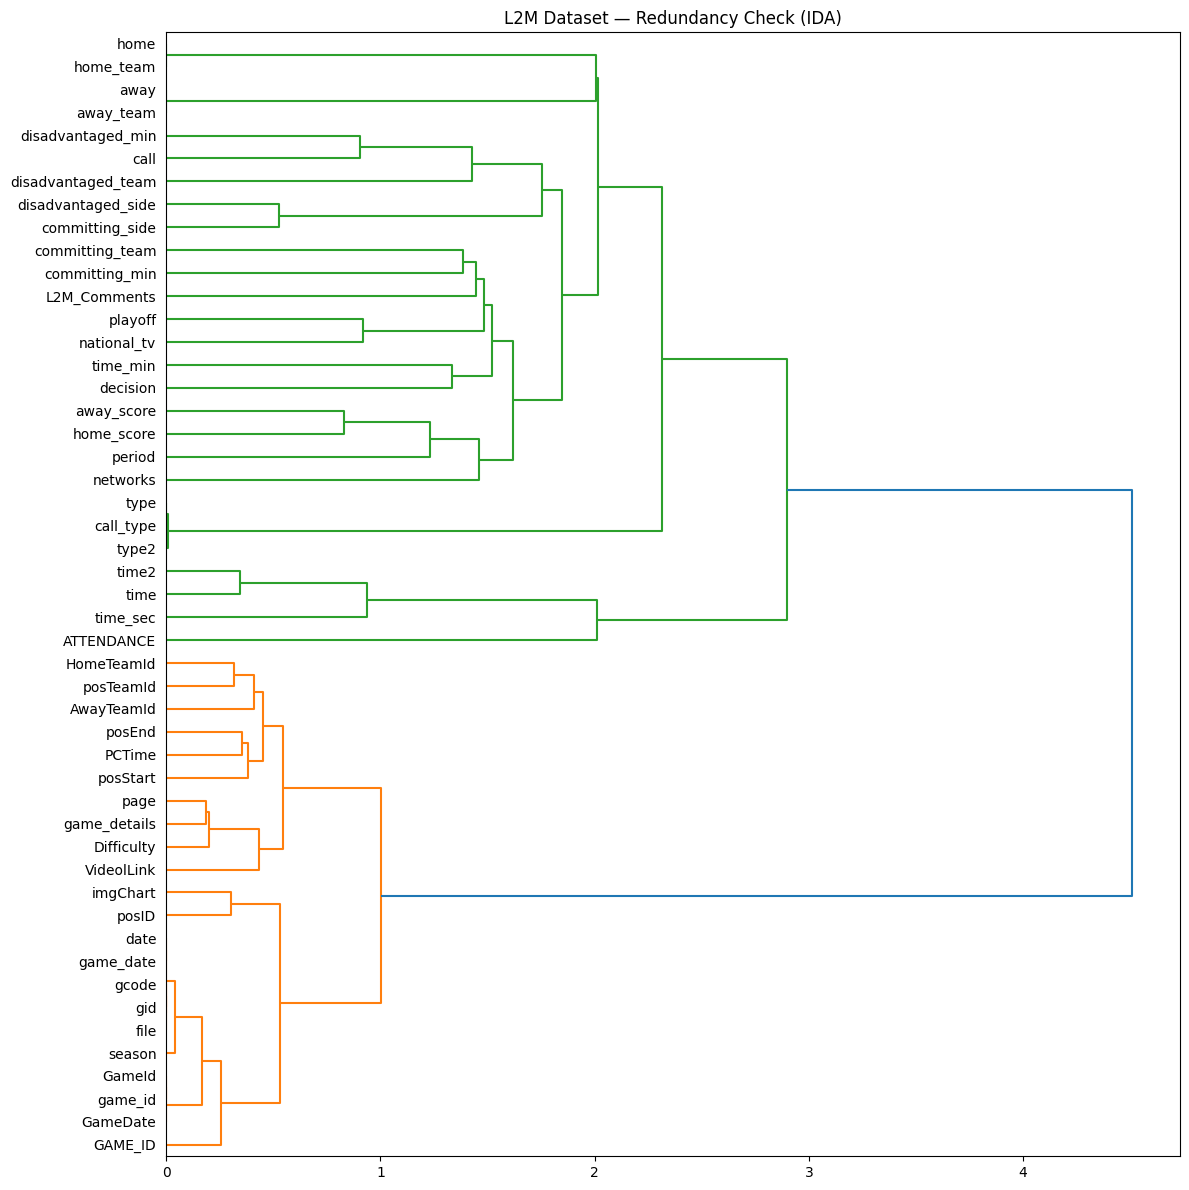

In [44]:
plot_redundancy(nba_data, title='L2M Dataset — Redundancy Check (IDA)')

> **Redundancy Check — L2M Dataset** — Two main clusters are identified. The **green cluster** contains all analytical variables: `home`, `away`, `home_team`, `away_team` cluster together (team identity redundancy — only abbreviations are retained); `committing_side`, `disadvantaged_side`, `committing_team`, `disadvantaged_team` cluster together (side and team are redundant — only side is needed); `decision`, `time_min`, `period` cluster in the analytical core group. The **orange cluster** groups all API-only and pipeline metadata fields: game ID duplicates (gid, game_id, GAME_ID, GameId, GameDate, game_date), position tracking fields (posID, posStart, posEnd, PCTime), and PDF pipeline artefacts (page, file, imgChart, VideolLink) — all candidates for exclusion. `ATTENDANCE` clusters independently, confirming it carries unique information not redundant with other fields.

> Candidate Variables - The column-level analysis identifies the following candidate variables for the central hypothesis. `decision` and `committing_side` are the core variables for calculating $\beta$ and $\delta$ as defined in Section 3.3. `call_type` provides the violation-specific base rates required by the Monte Carlo simulation. At the game level, `gid`, `date`, `home`, and `away` are the merge keys for linking L2M data with the betting dataset. `season` and `playoff` enable temporal segmentation across Pre-COVID, COVID, and Post-COVID periods. The merge is expected to be performed on `date`, `home`, and `away` --- compatibility of these fields with the betting dataset is examined in Section 4.2.4.

Based on the column-level analysis, the following columns are selected for the analytical dataset: `decision`, `committing_side`, `disadvantaged_side`, and `call_type`; `gid`, `date`, `season`, and `playoff` for game identification and temporal segmentation; `home`, `away`, `home_team`, and `away_team` for betting data merge; `ATTENDANCE` and `national_tv` for crowd pressure analysis; `home_score` and `away_score` for in-game context; `period`, `time`, `time_min`, `time_sec`, and `time2` for temporal play-level analysis; `committing_team` and `disadvantaged_team` for potential team-level analysis. All other columns are excluded as redundant, structurally incomplete, or not relevant to the research questions.

In [45]:
drop_cols = [
    # ID group — redundant with gid
    'GAME_ID', 'game_id', 'GameId', 'gcode',
    # Date group — redundant with date
    'game_date', 'GameDate',
    # Time group — structurally incomplete, redundant with time
    'PCTime',
    # Call group — redundant with call_type
    'call', 'type', 'type2',
    # Home group — structurally incomplete, redundant with home
    'HomeTeamId',
    # Away group — structurally incomplete, redundant with away
    'AwayTeamId',
    # Committing group — not used in analysis
    'committing_min',
    # Disadvantaged group — not used in analysis
    'disadvantaged_min',
    # Ungrouped — PDF pipeline artifacts
    'page', 'file', 'game_details',
    # Ungrouped — redundant with national_tv
    'networks',
    # Ungrouped — API columns, structurally incomplete or uninformative
    'teamIdInFavor', 'errorInFavor', 'Qualifier', 'ImposibleIndicator',
    'L2M_Comments', 'Difficulty', 'posID', 'posStart', 'posEnd',
    'posTeamId', 'imgChart', 'VideolLink'
]

print(nba_data.columns.tolist())
keep_cols = list(set(nba_data.columns.tolist()) - set(drop_cols))
print(keep_cols)
print(nba_data[keep_cols].head())

['period', 'time', 'call_type', 'decision', 'game_details', 'page', 'file', 'game_date', 'away_team', 'home_team', 'date', 'call', 'type', 'home', 'away', 'gid', 'gcode', 'home_score', 'away_score', 'national_tv', 'networks', 'game_id', 'PCTime', 'ImposibleIndicator', 'Difficulty', 'VideolLink', 'Qualifier', 'posID', 'posStart', 'posEnd', 'posTeamId', 'teamIdInFavor', 'errorInFavor', 'imgChart', 'GameId', 'GameDate', 'HomeTeamId', 'AwayTeamId', 'L2M_Comments', 'season', 'playoff', 'GAME_ID', 'ATTENDANCE', 'committing_min', 'committing_team', 'committing_side', 'disadvantaged_min', 'disadvantaged_team', 'disadvantaged_side', 'type2', 'time_min', 'time_sec', 'time2']
['home', 'decision', 'home_team', 'time_min', 'time', 'time_sec', 'away_team', 'away_score', 'call_type', 'national_tv', 'period', 'disadvantaged_side', 'playoff', 'disadvantaged_team', 'committing_side', 'ATTENDANCE', 'committing_team', 'date', 'season', 'away', 'gid', 'home_score', 'time2']
  home decision home_team  time_

### 4.2 NBA Betting Data

#### 4.2.1 Dataset Overview

The betting dataset is sourced from Kaggle [KaggleBetting] and covers all NBA games from October 2007 to June 2025. Scores, point spreads, totals, and other odds are included for each game. The dataset draws from two sources: Sportsbook Reviews Online for the period October 30, 2007 to January 16, 2023, and ESPN from January 17, 2023 onward. Each row represents a single game. The full list of variables is described in the source documentation [KaggleBetting].

Two notes from the source documentation are relevant for this study. First, second half and moneyline odds are absent from the ESPN-sourced data (since January 2023). Second, team abbreviations follow specific conventions: Seattle is encoded as `okc` and New Jersey as `bkn` for consistency across seasons.

#### 4.2.2 Data Quality

##### Shape

The dataset dimensions are inspected to confirm that the file was read correctly.

In [46]:
betting_data = pd.read_csv('data/input/nba_2008-2025.zip')
print(betting_data.head())
print(betting_data.shape)

   season        date  regular  playoffs  away home  score_away  score_home  \
0    2008  2007-10-30     True     False   por   sa          97         106   
1    2008  2007-10-30     True     False  utah   gs         117          96   
2    2008  2007-10-30     True     False   hou  lal          95          93   
3    2008  2007-10-31     True     False   phi  tor          97         106   
4    2008  2007-10-31     True     False   wsh  ind         110         119   

   q1_away  q2_away  ...  ot_home  whos_favored  spread  total  \
0       26       23  ...        0          home    13.0  189.5   
1       28       34  ...        0          home     1.0  212.0   
2       16       27  ...        0          away     5.0  199.0   
3       22       28  ...        0          home     6.5  191.0   
4       23       22  ...       16          away     1.5  203.5   

   moneyline_away  moneyline_home  h2_spread  h2_total id_spread  id_total  
0           900.0         -1400.0        5.0      9

> **Shape** --- The dataset contains $23{,}118$ rows and $27$ columns. The first few rows are displayed to verify the structure and content of the dataset.

##### Data Types

Inspecting the type of each column identifies potential parsing issues.

In [47]:
dtype_groups = betting_data.dtypes.reset_index()
dtype_groups.columns = ['column', 'dtype']
for dtype, group in dtype_groups.groupby('dtype'):
    print(f"\n{dtype}:")
    for col in group['column']:
        print(f"  {col}")


bool:
  regular
  playoffs

int64:
  season
  score_away
  score_home
  q1_away
  q2_away
  q3_away
  q4_away
  ot_away
  q1_home
  q2_home
  q3_home
  q4_home
  ot_home
  id_total

float64:
  spread
  total
  moneyline_away
  moneyline_home
  h2_spread
  h2_total
  id_spread

object:
  date
  away
  home
  whos_favored


> **Data Types** --- All 27 columns are inspected for parsing issues. A full description of each column is available in the source documentation [KaggleBetting]. `regular` and `playoffs` are `bool`, consistent with binary indicators in the source dataset. Score and quarter columns (`score_away`, `score_home`, `q1_away` through `ot_home`) are `int64` as expected. Betting columns (`spread`, `total`, `moneyline_away`, `moneyline_home`, `h2_spread`, `h2_total`, `id_spread`) are `float64` as expected. `id_total` is `int64`. Team identifier columns (`away`, `home`) and `whos_favored` are `object` as expected for string categories. One column requires conversion before analysis: `date` is stored as `object` and requires datetime conversion before merging with the L2M dataset. All conversions will be performed in the Tidy Data Preparation section.

##### Missing Values

The missing values analysis is the first step in column selection. Columns are evaluated by their missingness pattern to identify which are structurally incomplete and can be dropped before analysis.

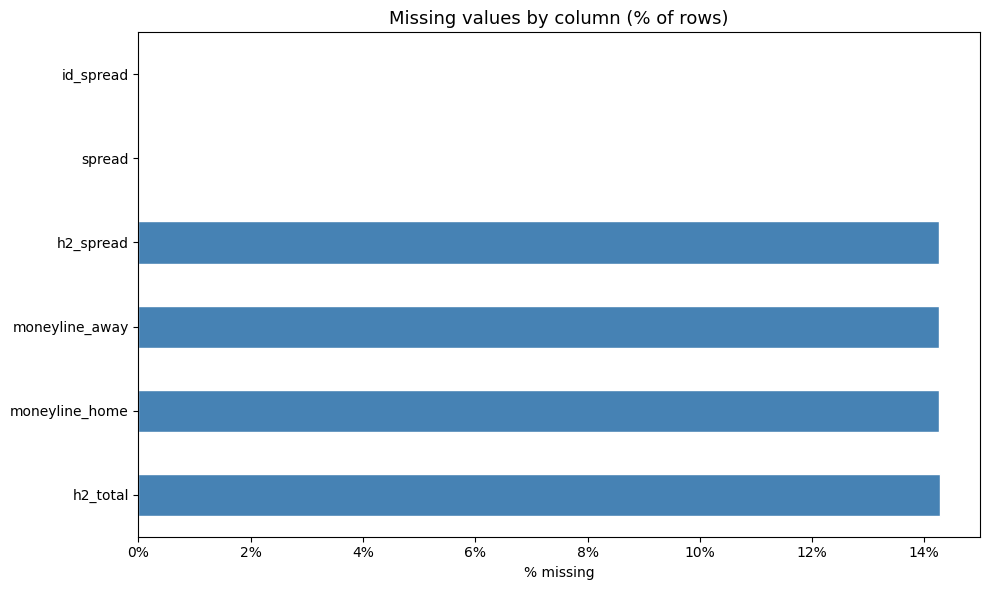

Columns with missing values: 6 / 27

h2_total          3301
moneyline_away    3298
moneyline_home    3298
h2_spread         3296
spread               3
id_spread            3


In [48]:
missing = betting_data.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(10, 6))
missing.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Missing values by column (% of rows)', fontsize=13)
ax.set_xlabel('% missing')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()
print(f"Columns with missing values: {len(missing)} / {len(betting_data.columns)}")
print(f"\n{betting_data.isnull().sum()[betting_data.isnull().sum() > 0].sort_values(ascending=False).to_string()}")

The three games with missing `spread` values are investigated to determine whether they can be recovered or should be excluded.

In [49]:
print("Games with missing spread:")
print(betting_data[betting_data['spread'].isnull()][['season', 'date', 'home', 'away', 'spread', 'id_spread']])

Games with missing spread:
       season        date home away  spread  id_spread
15939    2020  2019-12-19  lac  hou     NaN        NaN
18724    2022  2022-02-24  sac  den     NaN        NaN
18747    2022  2022-02-27  por  den     NaN        NaN


The three missing spread values correspond to two games from the 2022 season and one from the 2020 season. All three also have missing `id_spread`, confirming that the cover outcome is also unavailable for these games.

> **Missing Values** --- 6 out of 27 columns have missing values, falling into two structural groups. The first group comprises `h2_total` ($3{,}301$), `moneyline_away` ($3{,}298$), `moneyline_home` ($3{,}298$), and `h2_spread` ($3{,}296$) --- these correspond to the ESPN-sourced data from January 2023 onward, where second half and moneyline odds are absent by design as noted in the source documentation [KaggleBetting]. The second group contains `spread` and `id_spread` with 3 missing values each, corresponding to three specific games: LAC vs HOU (2019-12-19), SAC vs DEN (2022-02-24), and POR vs DEN (2022-02-27). These games have no spread data and will be excluded from the betting market analysis. The treatment of all missing values is deferred to the Tidy Data Preparation section.

##### Duplicates

Duplicate rows are identified to assess data integrity.

In [50]:
print(f"Duplicate rows: {betting_data.duplicated().sum()}")
print(f"Total rows: {len(betting_data)}")

Duplicate rows: 0
Total rows: 23118


> **Duplicates** --- The dataset contains no duplicate rows.

The categorical fields in the betting dataset are inspected to confirm structural consistency and identify any formatting issues prior to merging with the L2M dataset.

In [51]:
# Cardinality check for betting dataset
print("=== Cardinality Analysis — Betting Dataset ===")
print(f"{'Field':<25} {'Unique':>8}  {'Type':<10}  Sample values")
print("-" * 75)
for col in sorted(betting_data.columns):
    n = betting_data[col].nunique()
    dtype = str(betting_data[col].dtype)
    vals = betting_data[col].dropna().unique()
    sample = sorted([str(v) for v in vals if str(v) != 'nan'])[:4]
    print(f"  {col:<23} {n:>6}  {dtype:<10}  {sample}")

=== Cardinality Analysis — Betting Dataset ===
Field                       Unique  Type        Sample values
---------------------------------------------------------------------------
  away                        30  object      ['atl', 'bkn', 'bos', 'cha']
  date                      3688  object      ['2007-10-30', '2007-10-31', '2007-11-01', '2007-11-02']
  h2_spread                   37  float64     ['0.0', '0.5', '0.503', '0.505']
  h2_total                    84  float64     ['100.0', '100.5', '101.0', '101.5']
  home                        30  object      ['atl', 'bkn', 'bos', 'cha']
  id_spread                    3  float64     ['0.0', '1.0', '2.0']
  id_total                     3  int64       ['0', '1', '2']
  moneyline_away             665  float64     ['-1000.0', '-101.0', '-102.0', '-103.0']
  moneyline_home             674  float64     ['-1000.0', '-10000.0', '-1005.0', '-101.0']
  ot_away                     39  int64       ['0', '1', '10', '11']
  ot_home             

> **Cardinality Analysis**
>
> **Core analytical fields** — `id_spread` and `id_total` each have exactly 3 values (0, 1, 2) confirming the binary cover outcome plus push. `whos_favored` is strictly binary (home/away). `spread` has 46 unique values — all multiples of 0.5, with no formatting inconsistencies.
>
> **Game identification fields** — `playoffs` and `regular` are strictly boolean. `season` covers 18 seasons (2008–2025). `home` and `away` contain 30 unique team abbreviations in lowercase — requiring standardisation to uppercase before merging with the L2M dataset.
>
> **Score fields** — `score_home` and `score_away` have 100 and 106 unique values respectively, consistent with the expected range of NBA final scores. Quarter scores (q1–q4) have 44–49 unique values each, consistent with discrete integer scoring per quarter.
>
> **High-cardinality fields** — `moneyline_home` and `moneyline_away` have 674 and 665 unique values respectively, consistent with continuous odds values. `total` has 170 unique values. These fields are not used in the analysis.
>
> **Temporal coverage** — `date` has 3,688 unique values covering October 2007 to June 2025. The dataset contains 18 seasons compared to 11 in the L2M dataset — the overlap period (2015–2025) is applied during data preparation.

#### 4.2.3 Column-Level Analysis

The dataset contains 27 columns. Based on the source documentation [KaggleBetting] and the research questions defined in Section 3, a subset of columns is identified as candidates for analysis. The following sections examine each column group in detail, with the goal of determining which columns are suitable for inclusion in the final analytical dataset.

* **Game identifier group**: `season`, `date`, `home`, `away`, `regular`, `playoffs` --- columns identifying each game and its context.

In [52]:
id_cols = ['season', 'date', 'home', 'away', 'regular', 'playoffs']

print("Data types:")
for col in id_cols:
    print(f"  {col}: {betting_data[col].dtype}")

print("\nCoverage per column:")
for col in id_cols:
    print(f"  {col}: {betting_data[col].notna().sum()} / {len(betting_data)} ({betting_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in id_cols:
    print(f"  {col}: {betting_data[col].nunique()}")

print("\nSeason range:")
print(f"  {betting_data['season'].min()} - {betting_data['season'].max()}")

print("\nRegular/Playoffs split:")
print(betting_data['regular'].value_counts(dropna=False))
print(betting_data['playoffs'].value_counts(dropna=False))

Data types:
  season: int64
  date: object
  home: object
  away: object
  regular: bool
  playoffs: bool

Coverage per column:
  season: 23118 / 23118 (100.0%)
  date: 23118 / 23118 (100.0%)
  home: 23118 / 23118 (100.0%)
  away: 23118 / 23118 (100.0%)
  regular: 23118 / 23118 (100.0%)
  playoffs: 23118 / 23118 (100.0%)

Unique values:
  season: 18
  date: 3688
  home: 30
  away: 30
  regular: 2
  playoffs: 2

Season range:
  2008 - 2025

Regular/Playoffs split:
regular
True     21578
False     1540
Name: count, dtype: int64
playoffs
False    21611
True      1507
Name: count, dtype: int64


> **Game identifier group** --- All six columns have complete coverage (100%). `season` covers 18 seasons from 2008 to 2025. `date` is stored as `object` and requires datetime conversion before merging with the L2M dataset. `home` and `away` each have 30 unique values --- one per NBA team --- stored in lowercase format which differs from the L2M dataset. `regular` and `playoffs` are boolean columns with no missing values. The dataset contains $21{,}578$ regular season games and $1{,}507$ playoff games. Note that `regular` and `playoffs` are not mutually exclusive by design --- $1{,}540$ rows have `regular = False` while $1{,}507$ have `playoffs = True`, suggesting a small number of games may be neither regular season nor playoff (e.g. pre-season). `date`, `home`, and `away` are the merge keys for linking with the L2M dataset.

* **Score group**: `score_away`, `score_home`, `q1_away`, `q2_away`, `q3_away`, `q4_away`, `ot_away`, `q1_home`, `q2_home`, `q3_home`, `q4_home`, `ot_home` --- final and quarter-by-quarter scores for each game.

Score columns are examined to determine whether they should be treated as continuous or categorical variables. The number of unique values and the distribution are inspected.

In [53]:
score_cols = ['score_away', 'score_home', 'q1_away', 'q2_away', 'q3_away', 'q4_away',
              'ot_away', 'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home']

print("Unique values per column:")
for col in score_cols:
    print(f"  {col}: {betting_data[col].nunique()}")

Unique values per column:
  score_away: 106
  score_home: 100
  q1_away: 45
  q2_away: 46
  q3_away: 47
  q4_away: 45
  ot_away: 39
  q1_home: 46
  q2_home: 47
  q3_home: 49
  q4_home: 44
  ot_home: 39


All 12 score columns have complete coverage (100%). `score_away` and `score_home` have 106 and 100 unique values respectively, consistent with continuous numeric variables. Quarter columns (`q1` through `q4`) have 44--49 unique values each. `ot_away` and `ot_home` have 39 unique values --- the lower count reflects that most games do not go to overtime. The high number of unique values across all columns supports treating them as continuous numeric variables. For this study, only `score_away` and `score_home` are used to calculate the cover outcome. Quarter-by-quarter scores are not required for the analysis.

The distribution of score columns is visualized to determine whether they behave as continuous variables.


             min    max   mean  median
score_away  66.0  176.0  107.9   108.0
score_home  64.0  175.0  110.3   110.0


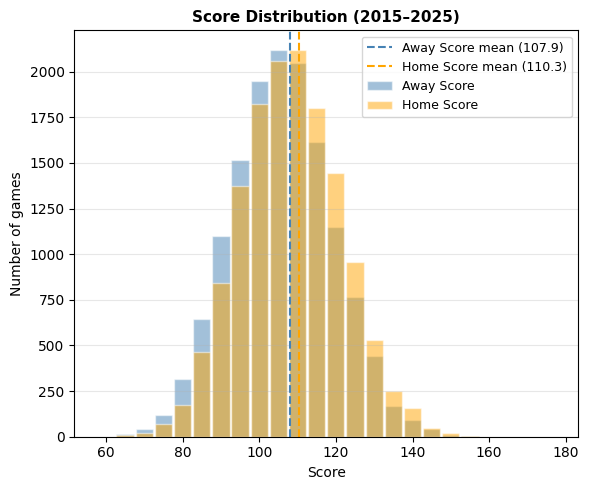

In [54]:
print(betting_data[betting_data['season'] >= 2015][['score_away', 'score_home']].agg(
    ['min', 'max', 'mean', 'median']
).round(1).T)


fig, ax = plt.subplots(figsize=(6, 5))

for col, color, label in [
    ('score_away', 'steelblue', 'Away Score'),
    ('score_home', 'orange', 'Home Score')
]:
    data_period = betting_data[betting_data['season'] >= 2015][col]
    bins = range(60, 185, 5)
    counts, edges = np.histogram(data_period, bins=bins)
    ax.bar(edges[:-1], counts, width=4.5, color=color, alpha=0.5,
           edgecolor='white', label=label)
    ax.axvline(data_period.mean(), color=color, linestyle='--', lw=1.5,
               label=f'{label} mean ({data_period.mean():.1f})')

ax.set_xlabel('Score', fontsize=10)
ax.set_ylabel('Number of games', fontsize=10)
ax.set_title('Score Distribution (2015–2025)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

> **Score distribution** --- `score_away` and `score_home` are discrete integer variables ranging from 66 to 176 and 64 to 175 respectively. Both distributions show a slight right skew — the right tail extends further than the left, reflecting occasional high-scoring games. The home team scores slightly higher on average ($110.3$ vs $107.9$), with near-identical mean and median values confirming the skew is mild. For this study, `score_away` and `score_home` are retained to derive `score_diff = score_home - score_away`. The cover outcome is derived from `id_spread` and `whos_favored` — not from the scores directly. `spread` is retained separately as a control variable in the logistic regression. Quarter-by-quarter scores are not required for the analysis and are excluded from the analytical dataset.

* **Betting group**: `whos_favored`, `spread`, `total`, `moneyline_away`, `moneyline_home` --- pre-game betting lines set by independent bookmakers.

Coverage and unique values are examined for all betting columns to identify structurally incomplete columns and determine the analytical value of each.

In [55]:

bet_cols = ['whos_favored', 'spread', 'total', 'moneyline_away', 'moneyline_home']
print(betting_data[bet_cols])
print("Coverage per column:")
for col in bet_cols:
    print(f"  {col}: {betting_data[col].notna().sum()} / {len(betting_data)} ({betting_data[col].notna().mean():.1%})")

print("\nUnique values per column:")
for col in bet_cols:
    print(f"  {col}: {betting_data[col].nunique()}")

      whos_favored  spread  total  moneyline_away  moneyline_home
0             home    13.0  189.5           900.0         -1400.0
1             home     1.0  212.0           100.0          -120.0
2             away     5.0  199.0          -230.0           190.0
3             home     6.5  191.0           255.0          -305.0
4             away     1.5  203.5          -125.0           105.0
...            ...     ...    ...             ...             ...
23113         away     4.5  225.5             NaN             NaN
23114         away     6.5  227.5             NaN             NaN
23115         home     8.5  223.5             NaN             NaN
23116         away     5.5  222.5             NaN             NaN
23117         home     6.5  215.5             NaN             NaN

[23118 rows x 5 columns]
Coverage per column:
  whos_favored: 23118 / 23118 (100.0%)
  spread: 23115 / 23118 (100.0%)
  total: 23118 / 23118 (100.0%)
  moneyline_away: 19820 / 23118 (85.7%)
  moneyline_home:

`whos_favored` and `spread` are examined together as they jointly define the cover outcome. `whos_favored` indicates which team is favored, while `spread` quantifies the expected margin. The distribution of both columns is examined.

In [56]:
print(betting_data['whos_favored'].value_counts(dropna=False))

whos_favored
home    15391
away     7727
Name: count, dtype: int64


> Home teams are favoured in $15{,}391$ games (66.6%) and away teams in $7{,}727$ games (33.4%) --- consistent with the well-documented home court advantage in the NBA.

`spread` and `score_diff` are examined for association. Both variables are discrete with natural ordering — Spearman rank correlation is used instead of Pearson, which assumes continuous normally distributed data, or Chi-square, which is appropriate for unordered categorical variables.


In [57]:
betting_data['score_diff'] = betting_data['score_home'] - betting_data['score_away']
clean = betting_data[['spread', 'score_diff']].dropna()
r, p = spearmanr(clean['spread'], clean['score_diff'])
print(f"Spearman r = {r:.4f},  p = {p:.4f}")

Spearman r = 0.2021,  p = 0.0000


> The Spearman rank correlation between `spread` and the actual point margin (`score_home - score_away`) is $r = 0.202$ --- positive and statistically meaningful, confirming that `spread` measures the expected point margin. The moderate correlation is expected --- bookmakers predict the direction and magnitude of the margin but cannot perfectly forecast the outcome. `spread` is confirmed as a numeric variable measured in half-point increments, on which arithmetic operations are meaningful. Together with `whos_favored`, it is retained as a core variable for the cover outcome calculation.
> `whos_favored` is a categorical variable with 2 unique values: `home` ($15{,}391$, 66.6%) and `away` ($7{,}727$, 33.4%). It determines the direction of the spread --- if `whos_favored = home`, the home team is expected to win by `spread` points; if `whos_favored = away`, the away team is expected to win by `spread` points. The cover outcome is therefore:
$$margin = \begin{cases} score\_home - score\_away & \text{if } whos\_favored = home \\ score\_away - score\_home & \text{if } whos\_favored = away \end{cases}$$

$$cover = \begin{cases} 1 & \text{if } margin > spread \\ 0 & \text{if } margin < spread \\ \text{excluded} & \text{if } margin = spread \end{cases}$$
`whos_favored` is retained as a core variable for the cover outcome calculation.

`total`, `moneyline_away`, and `moneyline_home` are examined for completeness and relevance to the central hypothesis.

In [58]:
# total — discrete, half-point increments
print("=== total ===")
print(betting_data['total'].agg(['min', 'max', 'mean', 'median', 'nunique']).round(1))

# moneyline — American odds format, coverage check only
print(f"\nmoneyline_away missing: {betting_data['moneyline_away'].isnull().sum()} ({betting_data['moneyline_away'].isnull().mean():.1%})")
print(f"moneyline_home missing: {betting_data['moneyline_home'].isnull().sum()} ({betting_data['moneyline_home'].isnull().mean():.1%})")

=== total ===
min        170.0
max        262.5
mean       210.2
median     210.0
nunique    170.0
Name: total, dtype: float64

moneyline_away missing: 3298 (14.3%)
moneyline_home missing: 3298 (14.3%)


> `total` (over/under) has complete coverage and 170 unique values, ranging from 170.0 to 262.5 points — this is the combined expected score for both teams, not an individual team score — with a mean of 210.2, consistent with expected NBA scoring totals. `moneyline_away` and `moneyline_home` have identical coverage (85.7%, $3{,}298$ missing) --- absent for ESPN-sourced data since January 2023 as noted in the source documentation [KaggleBetting]. Moneyline values are in American odds format --- negative values indicate favorites, positive values indicate underdogs. Not used in the analysis.

In [59]:
cols = ['total', 'moneyline_away', 'moneyline_home', 'spread', 'score_diff']
clean = betting_data[cols].dropna()

print("=== Spearman rank correlation ===")
corr_matrix = clean.apply(lambda x: clean.apply(lambda y: spearmanr(x, y)[0]))
print(corr_matrix.round(3).to_string())

=== Spearman rank correlation ===
                total  moneyline_away  moneyline_home  spread  score_diff
total           1.000          -0.035           0.033   0.030      -0.008
moneyline_away -0.035           1.000          -0.999   0.530       0.454
moneyline_home  0.033          -0.999           1.000  -0.531      -0.454
spread          0.030           0.530          -0.531   1.000       0.216
score_diff     -0.008           0.454          -0.454   0.216       1.000


> The correlation matrix confirms three structural patterns in the betting data. First, `moneyline_away` and `moneyline_home` are near-perfect mirror variables (r = −0.999) — both price the same game from opposite sides, which accounts for the near-perfect negative correlation.. Second, `spread` and moneyline are moderately correlated (r ≈ 0.53) — both measure expected team strength but in different formats. Third, `total` is effectively independent of all other variables (r < 0.04), confirming that the over/under line captures a separate dimension of the game — total scoring — unrelated to which team wins or by how much.

* **Second half group**: `h2_spread`, `h2_total` --- second half betting lines set by bookmakers at half-time based on first half performance. These lines have no direct relevance to the central hypothesis as L2M data covers only the final two minutes of each period. Examined for completeness only.

Coverage and descriptive statistics are examined. The correlation between `h2_spread`, `h2_total` and the core variables is examined.

In [60]:
print(betting_data[['h2_spread', 'h2_total']].head())
print(betting_data[['h2_spread', 'h2_total', 'spread', 'score_diff']].corr())

   h2_spread  h2_total
0        5.0      95.0
1        3.0     105.5
2        3.0      99.0
3        2.0      96.5
4        1.0     105.0
            h2_spread  h2_total    spread  score_diff
h2_spread    1.000000  0.053773  0.411521   -0.042665
h2_total     0.053773  1.000000  0.025311   -0.025358
spread       0.411521  0.025311  1.000000    0.215968
score_diff  -0.042665 -0.025358  0.215968    1.000000


> `h2_spread` shows moderate correlation with `spread` ($r = 0.412$) --- both measure the expected point margin but at different points in time: `spread` is set before the game, `h2_spread` is set at half-time based on first half performance [KaggleBetting]. `h2_total` shows near-zero correlation with all other variables ($r < 0.06$). Neither column correlates meaningfully with `score_diff` ($r = -0.043$ and $r = -0.025$ respectively). Both columns are not retained for analysis.

* **Outcome group**: `id_spread`, `id_total` --- post-game outcomes. According to the source documentation [KaggleBetting]: `id_spread` is 1 if the favorite covered, 0 if the underdog covered, 2 if push. `id_total` is 1 if the total went over, 0 if under, 2 if push.

The distribution and relevance to the central hypothesis are examined.

In [61]:
print(betting_data[['id_spread', 'id_total']].value_counts(dropna=False))

id_spread  id_total
1.0        0           5696
0.0        1           5644
           0           5615
1.0        1           5558
2.0        1            182
           0            151
1.0        2            142
0.0        2            125
2.0        2              2
NaN        1              2
           0              1
Name: count, dtype: int64


> `id_spread` and `id_total` are post-game outcome variables. `id_spread` records whether the favorite covered the spread: 1 (favorite covered), 0 (underdog covered), 2 (push). `id_total` records whether the total went over: 1 (over), 0 (under), 2 (push). Both have 3 missing values --- the same games with missing `spread` identified earlier. Push outcomes are rare: 142 for `id_spread` and 182 for `id_total`. `id_spread` is noted as a candidate for the cover outcome calculation --- however, it is defined from the perspective of the **favorite**, not the **home team**. Since the central hypothesis requires cover from the perspective of the home team, `id_spread` cannot be used directly and a new `home_cover` variable will be derived in the Tidy Data Preparation section. `id_total` is not relevant to the central hypothesis.

#### 4.2.4 Summary

Based on the column-level analysis and the central hypothesis $H_1: P(\text{cover} \mid NWG > 0) \neq 0.50$, the following columns are retained for the analytical dataset: `date`, `home`, and `away` for merging with the L2M dataset; `season` and `playoffs` for temporal segmentation; `score_home`, `score_away`, `whos_favored`, `spread`, and `id_spread` for deriving the `home_covered` outcome variable.

The following columns are excluded based on the IDA findings above. `regular` is a mirror variable of `playoffs` (distance 0 in the redundancy check) — only one is needed. `moneyline_home` and `moneyline_away` have 3,298 missing values each, corresponding to all ESPN-sourced games from January 2023 onward, and correlate with `spread` (r≈0.53) — they measure the same pre-game expectation in a different format. `h2_spread` and `h2_total` have 3,296 and 3,301 missing values respectively for the same reason, and are half-time lines — not pre-game measures. `total` and `id_total` test the over/under market, which is structurally independent of the spread outcome (r<0.04). Quarter scores (`q1`–`q4`, `ot`) are redundant with `score_home` and `score_away` — they sum to the final score by definition.

> **Summary** — The betting dataset contains 23,118 games across seasons 2008–2025. After filtering to seasons 2015–2025 to match the L2M coverage period and dropping the three games with missing `spread`, the analytical subset contains 14,154 games. Home teams are favoured in 66.6% of games. The `id_spread` outcome variable is complete for 99.9% of games. No duplicate rows are present. The dataset is structurally clean and ready for merge with the L2M game-level data.

/tmp/ipykernel_3022/2956773671.py:36: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  dist_linkage = hierarchy.linkage(distance_matrix, method='complete')


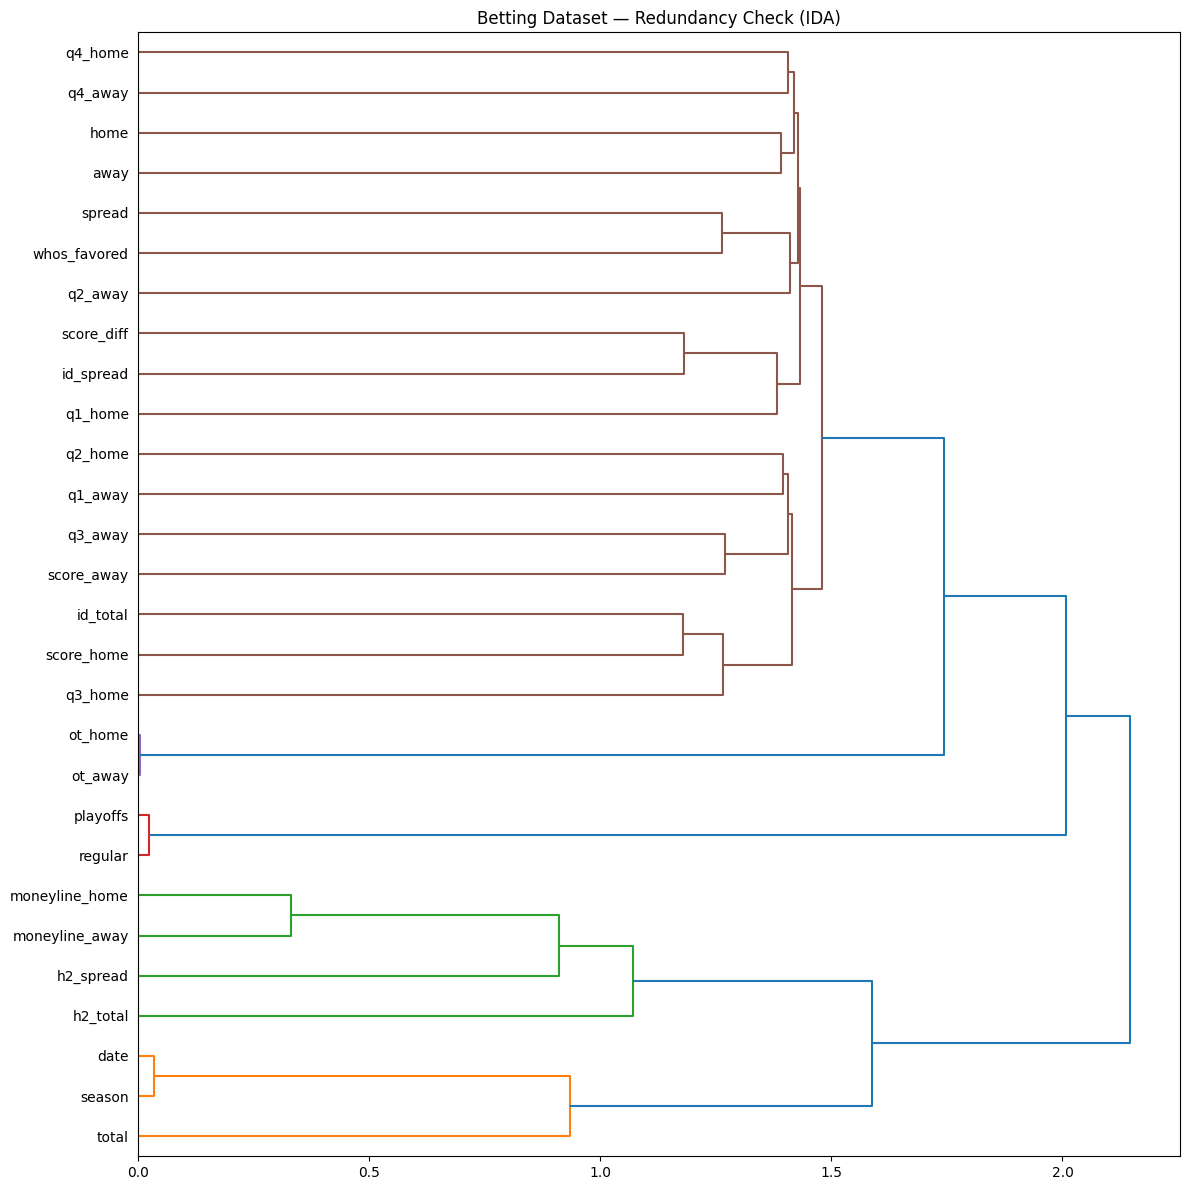

In [62]:
plot_redundancy(betting_data, title='Betting Dataset — Redundancy Check (IDA)')

> **Redundancy Check — Betting Dataset** — Four distinct clusters are identified. The **red cluster** groups all post-game measurements: quarter scores (`q1`–`q4`, `ot`), final scores (`score_home`, `score_away`), `score_diff`, `id_spread`, and `id_total` — all structurally correlated because they measure outcomes of the same game. `spread` and `whos_favored` cluster together at low distance, confirming they jointly define the pre-game market expectation. `playoffs` and `regular` form a near-identical pair (distance 0) — they are mirror variables encoding the same information from opposite sides. The **green cluster** groups `moneyline_home`, `moneyline_away`, `h2_spread`, and `h2_total` — all four have over 3,296 missing values (absent from ESPN source from January 2023 onward) and measure secondary betting lines correlated with `spread` (moneyline r≈0.53, h2_spread r=0.412). The **orange cluster** groups `date`, `season`, and `total` — temporally related but structurally independent from the score cluster (`total` r<0.04 with all other variables).

## 5. Data Engineering

### 5.1 L2M Preparation

The raw L2M dataset ($90{,}302$ rows, $53$ columns) is prepared in two stages.

**Stage 1 — `nba_meta`**: 
First, $23$ analytical columns are retained based on the column-level analysis in Section 4.1.3.  
Second, `date` is converted to datetime and `playoff` to integer (0/1).  
Third, duplicate rows that emerge after column selection are removed.  
Fourth, blank decisions representing plays not detectable without technology are dropped. The resulting `nba_meta` dataset serves as the base for all downstream analytical datasets.

**Stage 2 — `auxiliary_data`**: Following Pelechrinis (2023) [PelechrinisL2M], CNC entries are excluded as their grading criteria are inconsistent across seasons. The resulting `auxiliary_data` contains only CC, IC, and INC decisions and is used for the auxiliary hypothesis.

Before applying any filters, the missing values in the three core analytical columns --- `decision`, `committing_side`, and `disadvantaged_side` --- are examined to determine which can be safely dropped and which must be retained.

In [63]:
print("=== decision ===")
print(nba_data['decision'].value_counts(dropna=False))

print("\n=== committing_side — decision distribution where NaN ===")
print(nba_data[nba_data['committing_side'].isna()]['decision'].value_counts(dropna=False))
print("\nTop call_type:")
print(nba_data[nba_data['committing_side'].isna()]['call_type'].value_counts().head(5))

print("\n=== disadvantaged_side — decision distribution where NaN ===")
print(nba_data[nba_data['disadvantaged_side'].isna()]['decision'].value_counts(dropna=False))
print("\nTop call_type:")
print(nba_data[nba_data['disadvantaged_side'].isna()]['call_type'].value_counts().head(5))

=== decision ===
decision
CNC    60590
CC     21023
INC     5391
NaN     2502
IC       796
Name: count, dtype: int64

=== committing_side — decision distribution where NaN ===
decision
CC     1566
CNC     719
NaN      81
INC      44
IC       23
Name: count, dtype: int64

Top call_type:
call_type
Instant Replay: Support Ruling     787
Foul: Personal                     290
Foul: Shooting                     288
Instant Replay: Overturn Ruling    265
Turnover: 24 Second Violation      191
Name: count, dtype: int64

=== disadvantaged_side — decision distribution where NaN ===
decision
CC     1971
NaN    1617
CNC    1501
INC     666
IC       46
Name: count, dtype: int64

Top call_type:
call_type
Turnover: Traveling               1538
Instant Replay: Support Ruling     846
Foul: Defense 3 Second             485
Turnover: 3 Second Violation       335
Foul: Personal                     313
Name: count, dtype: int64


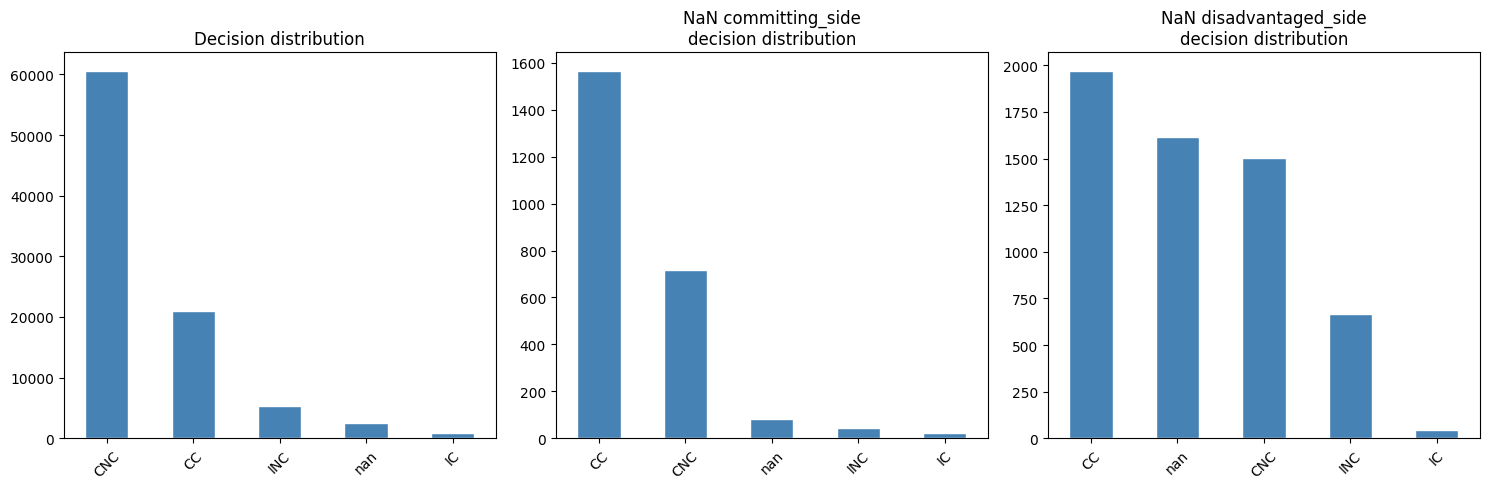

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nba_data['decision'].value_counts(dropna=False).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Decision distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

nba_data[nba_data['committing_side'].isna()]['decision'].value_counts(dropna=False).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('NaN committing_side\ndecision distribution')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

nba_data[nba_data['disadvantaged_side'].isna()]['decision'].value_counts(dropna=False).plot(
    kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('NaN disadvantaged_side\ndecision distribution')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> **Observation** --- `decision` has $2{,}502$ missing values representing plays not detectable without technology --- these are dropped. CNC ($60{,}590$) is excluded as its grading criteria are inconsistent across seasons [PelechrinisL2M]. Missing values in `committing_side` ($2{,}433$) are dominated by Instant Replay rulings and technical violations where no specific player is identified by definition, and contain 67 incorrect decisions (IC + INC) --- retained. Missing values in `disadvantaged_side` ($5{,}801$) follow the same pattern, dominated by structural violations (Traveling, Defense 3-second) and contain $712$ incorrect decisions --- retained.

> Missing values in `committing_side` and `disadvantaged_side` are retained because they contain real referee errors. Among the $2{,}433$ rows with missing `committing_side`, 67 are incorrect decisions (IC + INC, 2.7%). Among the $5{,}801$ rows with missing `disadvantaged_side`, $712$ are incorrect decisions (IC + INC, 12.3%). These missing values do not indicate data quality issues --- they arise from play types where no specific player is identified by definition, such as Instant Replay rulings ($787$ and $846$ respectively) and structural violations (Traveling: $1{,}538$, Defense 3-second: $485$). Removing them would discard valid analytical signal from the working dataset.



Stage 1 — `nba_meta` is created by applying column selection, type conversions, duplicate removal, and blank decision removal.

In [65]:
# Step 1 — Apply column selection
cols_before = len(nba_data.columns)
nba_meta = nba_data[keep_cols].copy()
print(f"Columns: {cols_before} → {len(nba_meta.columns)}")

# Step 2 — Type conversions
nba_meta['date'] = pd.to_datetime(nba_meta['date'])
nba_meta['playoff'] = nba_meta['playoff'].astype(int)

# Step 3 — Drop duplicates
rows_before = len(nba_meta)
nba_meta = nba_meta.drop_duplicates()
print(f"After drop duplicates: {len(nba_meta)} (dropped {rows_before - len(nba_meta)})")

# Step 4 — Drop blank decisions
rows_before = len(nba_meta)
nba_meta = nba_meta[nba_meta['decision'].notna()].copy()
print(f"After drop decision NaN: {len(nba_meta)} (dropped {rows_before - len(nba_meta)})")
print(f"\nFinal nba_meta: {nba_meta.shape}")

Columns: 53 → 23
After drop duplicates: 89460 (dropped 842)
After drop decision NaN: 86963 (dropped 2497)

Final nba_meta: (86963, 23)


Stage 2 --- `auxiliary_data` is derived from `nba_meta` by excluding CNC entries. Following Pelechrinis (2023) [PelechrinisL2M], CNC entries are excluded. While CC, IC and INC decisions are well-defined, CNC decisions are subjective and their reporting criteria changed substantially across seasons --- from $6.4$ entries per game in 2015 to almost $14$ in 2022. As stated in the reference study: *"any analysis should not rely on CNC data points since they are not consistent across seasons"* [PelechrinisL2M].

In [66]:
# Stage 2 — RQ1 dataset — play-level, IC/INC/CC without CNC
auxiliary_data = nba_meta[nba_meta['decision'].isin(['CC', 'IC', 'INC'])].copy()
print(f"Shape: {auxiliary_data.shape}")
print(f"\nDecision distribution:")
print(auxiliary_data['decision'].value_counts())

Shape: (27127, 23)

Decision distribution:
decision
CC     20958
INC     5374
IC       795
Name: count, dtype: int64


Following Pelechrinis (2023) [PelechrinisL2M], the whistle benefit $\beta$ and whistle detriment $\delta$ are defined solely by `committing_side` and `decision`. An incorrect non-call (INC) where the committing team is home means the home team escaped a penalty --- a benefit to the home team. An incorrect call (IC) where the committing team is away means the away team was wrongly penalized --- again a benefit to the home team. The `disadvantaged_side` column serves as a consistency check but is not required for this calculation.

| $committing\_side$ | $disadvantaged\_side$ | $decision$ | Benefit |
|---|---|---|---|
| $home$ | $away$ | $INC$ | $home\ (\beta)$ |
| $away$ | $home$ | $IC$ | $home\ (\beta)$ |
| $away$ | $home$ | $INC$ | $away\ (\delta)$ |
| $home$ | $away$ | $IC$ | $away\ (\delta)$ |
| $home$ | $away$ | $CC$ | neutral |
| $away$ | $home$ | $CC$ | neutral |
| $home$ | $home$ | $*$ | anomaly |
| $away$ | $away$ | $*$ | anomaly |


The `auxiliary_data` is the play-level working dataset derived from `nba_meta` by excluding CNC decisions. Each row represents a single graded play with the following variables:

- `decision` (CC, IC, INC) --- the referee's grading of the play, as defined in Section 4.1.3
- `committing_side` (home/away) --- the team that committed the infraction, used to determine the direction of the error ($\beta$ and $\delta$), as defined in Section 3.3
- `call_type` --- the type of infraction, used to compute base rates for the Monte Carlo simulation, as defined in Section 4.1.3
- `period`, `time` --- temporal context of the play
- `season`, `playoff` --- for period segmentation (Pre-COVID, COVID, Post-COVID) as defined in Section 3.3
- `gid` --- game identifier for aggregation

The `auxiliary_data` is saved to disk for use in downstream analysis.

In [67]:
auxiliary_data.to_csv('data/output/auxiliary_data.csv', index=False)

### 5.2 Betting Data Preparation

The betting dataset ($23{,}118$ rows, $27$ columns) is prepared in three steps. First, games before season 2015 are filtered out to match the L2M coverage period. Second, the three games with missing `spread` values are dropped. Third, `date` is converted to datetime and team abbreviations are converted to uppercase to match the L2M dataset.

Games before season 2015 are filtered out to match the L2M coverage period.

In [68]:
# Step 1 — Filter to L2M coverage period
rows_before = len(betting_data)
betting_clean = betting_data[betting_data['season'] >= 2015].copy()
print(f"After season filter: {len(betting_clean)} (dropped {rows_before - len(betting_clean)})")

After season filter: 14157 (dropped 8961)


The three games with missing `spread` values are dropped as the cover outcome cannot be computed without a spread.

In [69]:
# Step 2 — Drop missing spread
rows_before = len(betting_clean)
betting_clean = betting_clean[betting_clean['spread'].notna()].copy()
print(f"After drop missing spread: {len(betting_clean)} (dropped {rows_before - len(betting_clean)})")

After drop missing spread: 14154 (dropped 3)


`date` is converted to datetime and team abbreviations are converted to uppercase to match the L2M dataset.

In [70]:
# Step 3 — Type conversions and abbreviation standardization
betting_clean['date'] = pd.to_datetime(betting_clean['date'])
betting_clean['home'] = betting_clean['home'].str.upper()
betting_clean['away'] = betting_clean['away'].str.upper()

print(f"\nFinal betting dataset: {betting_clean.shape}")
print(f"\nSample team abbreviations:")
print(betting_clean[['home', 'away']].head(3))


Final betting dataset: (14154, 28)

Sample team abbreviations:
     home away
8961   SA  DAL
8962   NO  ORL
8963  LAL  HOU


After uppercase conversion, team abbreviations are compared with the L2M dataset to identify mismatches.

In [71]:
l2m_teams = set(nba_meta['home'].unique()) | set(nba_meta['away'].unique())
bet_teams = set(betting_clean['home'].unique()) | set(betting_clean['away'].unique())

print("In betting but not in L2M:")
print(bet_teams - l2m_teams)
print("\nIn L2M but not in betting:")
print(l2m_teams - bet_teams)

In betting but not in L2M:
{'GS', 'UTAH', 'SA', 'WSH', 'NY', 'NO'}

In L2M but not in betting:
{'WAS', 'UTA', 'NYK', 'NOP', 'SAS', 'GSW'}


Six team abbreviation mismatches are identified between the betting and L2M datasets. A mapping is applied to standardize the betting dataset abbreviations to match the L2M format.

In [72]:
# Step 4 — Standardize team abbreviations
abbrev_map = {
    'WSH': 'WAS',
    'GS': 'GSW',
    'NY': 'NYK',
    'SA': 'SAS',
    'NO': 'NOP',
    'UTAH': 'UTA'
}

betting_clean['home'] = betting_clean['home'].replace(abbrev_map)
betting_clean['away'] = betting_clean['away'].replace(abbrev_map)

# Verify
l2m_teams = set(nba_meta['home'].unique()) | set(nba_meta['away'].unique())
bet_teams = set(betting_clean['home'].unique()) | set(betting_clean['away'].unique())
print("Remaining mismatches:")
print(bet_teams - l2m_teams)

Remaining mismatches:
set()


> All six team abbreviation mismatches are resolved. The betting dataset team abbreviations are now fully consistent with the L2M dataset.

### 5.3 Merge

The L2M data is first aggregated to game level to compute $\beta$ and $\delta$ for each game. The resulting game-level dataset is then merged with the betting data on `date`, `home`, and `away`.

The game-level aggregation is computed from `nba_meta` — the cleaned play-level dataset derived in Section 5.1 containing all CC, IC, and INC decisions. For each game, β and δ are computed using the full Pelechrinis (2023) formula across all plays, retaining rows with missing `committing_side` and `disadvantaged_side` as they contain valid incorrect decisions as documented in Section 4.1.

In [73]:
# Define play-level and game-level columns
play_level_cols = ['decision', 'committing_side', 'committing_team',
                   'disadvantaged_side', 'disadvantaged_team',
                   'call_type', 'period',
                   'time', 'time2', 'time_min', 'time_sec']
game_cols = set(nba_meta.columns.tolist()) - set(play_level_cols)

# Aggregate all plays from nba_meta — CC rows contribute to n_plays but not to β/δ
# committing_side and disadvantaged_side NaN rows are retained (valid signal)
l2m_plays = nba_meta.copy()
l2m_plays['side_decision'] = (
    l2m_plays['committing_side'].fillna('unknown') + '_' +
    l2m_plays['decision']
)

# Aggregate β and δ using Pelechrinis full formula
# β = INC(committing=home) + IC(disadvantaged=home)
# δ = INC(disadvantaged=home) + IC(committing=home)
def calc_beta_delta(df):
    beta  = ((df['committing_side']=='home') & (df['decision']=='INC')).sum() + \
            ((df['disadvantaged_side']=='home') & (df['decision']=='IC')).sum()
    delta = ((df['disadvantaged_side']=='home') & (df['decision']=='INC')).sum() + \
            ((df['committing_side']=='home') & (df['decision']=='IC')).sum()
    home_IC  = ((df['committing_side']=='home') & (df['decision']=='IC')).sum()
    home_INC = ((df['committing_side']=='home') & (df['decision']=='INC')).sum()
    away_IC  = ((df['committing_side']=='away') & (df['decision']=='IC')).sum()
    away_INC = ((df['committing_side']=='away') & (df['decision']=='INC')).sum()
    return pd.Series({
        'beta':     int(beta),
        'delta':    int(delta),
        'home_IC':  int(home_IC),
        'home_INC': int(home_INC),
        'away_IC':  int(away_IC),
        'away_INC': int(away_INC),
        'n_plays':  len(df)
    })

# Get game-level metadata
game_meta = l2m_plays[sorted(game_cols)].drop_duplicates('gid')

# Aggregate decisions by game
game_decisions = l2m_plays.groupby('gid').apply(
    calc_beta_delta, include_groups=False
).reset_index()

# Merge
nba_games = game_meta.merge(game_decisions, on='gid', how='left')

print(f"Shape: {nba_games.shape}")
print(f"Unique games: {nba_games['gid'].nunique()}")
print(nba_games[['gid','beta','delta','home_IC','home_INC','away_IC','away_INC','n_plays']].head(5))

Shape: (4487, 19)
Unique games: 4487
        gid  beta  delta  home_IC  home_INC  away_IC  away_INC  n_plays
0  21400883     1      2        0         1        0         2       21
1  21400880     2      0        0         2        0         0        9
2  21400884     0      1        0         0        0         1       13
3  21400886     0      0        0         0        0         0        8
4  21400888     2      2        0         1        1         2       15


$\beta$, $\delta$, $NWG$, and $AR$ are computed for each game following the definitions in Section 3.3.

The game-level L2M dataset (`nba_games`) is merged with the betting dataset (`betting_clean`) on `date`, `home`, and `away`. Only the columns needed for the central hypothesis are taken from `betting_clean` — the full justification for each is in Section 4.2.3 and 4.2.4. `whos_favored` and `spread` jointly define the pre-game market expectation. `id_spread` is the post-game cover outcome. `score_home` and `score_away` are used to compute `score_diff` and are verified against the L2M scores in Section 5.4.2, after which they are dropped. The remaining columns in `betting_clean` are excluded: `moneyline_home` and `moneyline_away` have 3,298 missing values each and correlate with `spread` (r≈0.53); `h2_spread` and `h2_total` have 3,296 and 3,301 missing values respectively and are half-time lines; `total` and `id_total` test the over/under market (r<0.04 with all other variables); quarter scores are redundant with `score_home` and `score_away`; `regular` is a mirror of `playoffs`.

The merge is performed in three steps.  
* First, `nba_games` is merged with the selected columns from `betting_clean` on `date`, `home`, and `away`.  
* Second, the `home_covered` outcome variable is derived from `whos_favored` and `id_spread`. Games where the final margin equals the spread exactly (`id_spread = 2`) are pushes — no winner, stakes returned — and are set to NaN.
* Third, `score_diff` is computed as the difference between home and away final scores, and `period` is derived from `season` using the crowd presence boundaries defined in Section 3.3.1.

In [74]:
# Step 1 — Merge nba_games with betting_clean on date + home + away
master = nba_games.merge(
    betting_clean[['date','home','away','whos_favored',
                   'spread','id_spread','score_home','score_away']],
    on=['date','home','away'],
    how='left'
)

# Step 2 — Compute home_covered
master['home_fav'] = (master['whos_favored'] == 'home').astype(float)
master['home_covered'] = np.where(
    master['id_spread'] == 2, np.nan,
    np.where(master['home_fav'] == 1,
             (master['id_spread'] == 1).astype(float),
             (master['id_spread'] == 0).astype(float))
)

# Step 3 — Score diff and period
master['score_diff'] = master['score_home'] - master['score_away']
master['period'] = pd.cut(master['season'],
    bins=[2014, 2019, 2022, 2026],
    labels=['Pre-COVID', 'COVID', 'Post-COVID'])

print(f"Master shape:       {master.shape}")
print(f"Matched with odds:  {master['spread'].notna().sum()}")
print(f"Match rate:         {master['spread'].notna().mean():.1%}")
print(f"home_covered NaN:   {master['home_covered'].isna().sum()} (pushes)")


Master shape:       (4487, 28)
Matched with odds:  4485
Match rate:         100.0%
home_covered NaN:   109 (pushes)


NWG, AR, and NWG_direction are computed from $\beta$ and $\delta$ as defined in Section 3.2. The distribution of NWG across all games is printed to verify the expected right-skew — more games with positive NWG than negative — and the sum of NWG is checked against the t_real value used in the Monte Carlo simulation in Section 7.1.

In [75]:
master['NWG'] = master['beta'] - master['delta']
master['AR']  = master['beta'] / (master['beta'] + master['delta'])
master['NWG_direction'] = pd.cut(master['NWG'], bins=[-20, -1, 0, 20], labels=['NWG < 0', 'NWG = 0', 'NWG > 0'])

print("NWG distribution:")
print(master['NWG'].describe().round(3))
print(f"\nNWG > 0: {(master['NWG'] > 0).sum()} games")
print(f"NWG = 0: {(master['NWG'] == 0).sum()} games")
print(f"NWG < 0: {(master['NWG'] < 0).sum()} games")
print(f"\nAR defined (≥1 error): {master['AR'].notna().sum()} games")
print(f"AR = NaN  (0 errors):  {master['AR'].isna().sum()} games")
print(f"\nSum NWG (should be ≈ 403): {master['NWG'].sum()}")

NWG distribution:
count    4487.000
mean        0.090
std         1.156
min        -5.000
25%        -1.000
50%         0.000
75%         1.000
max         6.000
Name: NWG, dtype: float64

NWG > 0: 1399 games
NWG = 0: 1942 games
NWG < 0: 1146 games

AR defined (≥1 error): 3047 games
AR = NaN  (0 errors):  1440 games

Sum NWG (should be ≈ 403): 403


> **Observation** — The game-level dataset contains 4,487 unique games across seasons 2015–2025. NWG has a mean of 0.090 and ranges from −5 to +6, consistent with the expected small directional signal in close games. The sum of NWG across all games equals 403, which matches the t_real value computed by the Pelechrinis formula — confirming the aggregation is correct. Of the 4,487 games, 3,047 have at least one referee error (AR computable) while 1,440 games had zero errors in the final two minutes and are excluded from AR-based analysis but retained for NWG analysis.

In [76]:
print(f"Games with AR = NaN: {master['AR'].isna().sum()}")
print(f"Games with AR defined: {master['AR'].notna().sum()}")

Games with AR = NaN: 1440
Games with AR defined: 3047


> **Observation** — Games with zero referee errors (AR = NaN, n = 1,440) are retained in the master dataset. These games have NWG = 0 by definition and carry valid analytical signal — a game with no errors is a neutral observation, not missing data. Two analytical subsets are used throughout the analysis: the full dataset (n = 4,466 games) for all NWG-based analysis including the binomial test, logistic regression, and cover rate groups; and the AR subset (n = 3,047 games) restricted to games with at least one referee error, used only where AR is the explicit measure of interest. All subset choices are documented at the point of use.

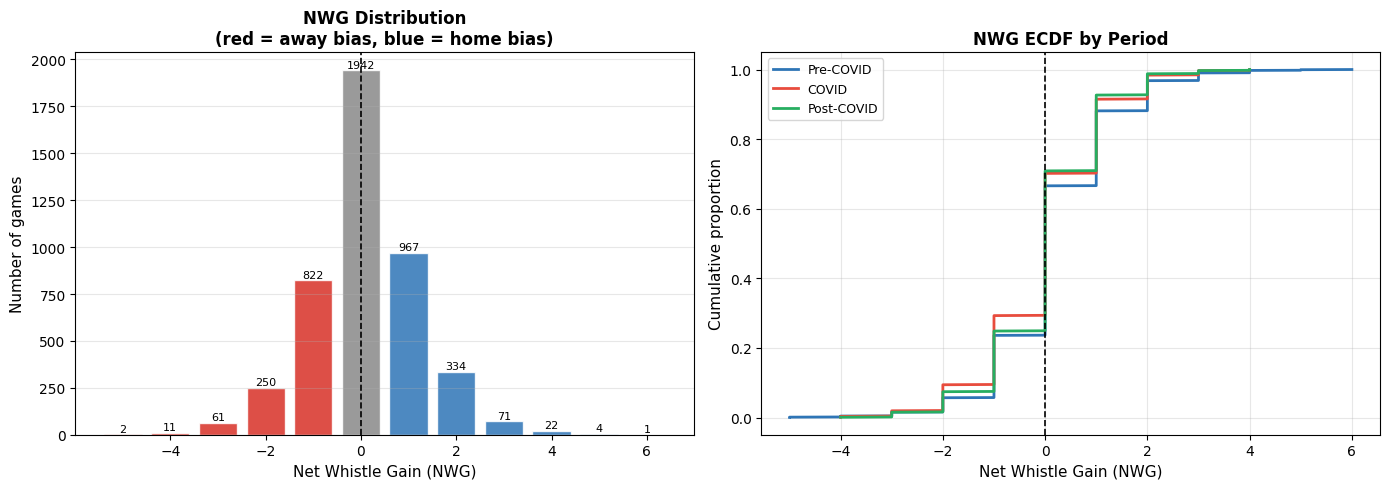

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — NWG distribution bar chart
nwg_counts = master['NWG'].value_counts().sort_index()
colors = ['#d73027' if x < 0 else '#2E75B6' if x > 0 else '#888888' 
          for x in nwg_counts.index]
axes[0].bar(nwg_counts.index, nwg_counts.values, color=colors, 
            alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', lw=1.2)
axes[0].set_xlabel('Net Whistle Gain (NWG)', fontsize=11)
axes[0].set_ylabel('Number of games', fontsize=11)
axes[0].set_title('NWG Distribution\n(red = away bias, blue = home bias)', 
                  fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for x, y in zip(nwg_counts.index, nwg_counts.values):
    axes[0].text(x, y + 15, str(y), ha='center', fontsize=8)

# Right — cumulative % by period
for per, color in [('Pre-COVID','#2E75B6'),('COVID','#E84C3D'),('Post-COVID','#27AE60')]:
    sub = master[master['period']==per]['NWG'].sort_values()
    ecdf = np.arange(1, len(sub)+1) / len(sub)
    axes[1].plot(sub, ecdf, color=color, lw=2, label=per)
axes[1].axvline(0, color='black', linestyle='--', lw=1.2)
axes[1].set_xlabel('Net Whistle Gain (NWG)', fontsize=11)
axes[1].set_ylabel('Cumulative proportion', fontsize=11)
axes[1].set_title('NWG ECDF by Period', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/output/nwg_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observation** — The master dataset contains 4,487 games with a match rate of 99.96% (4,485 of 4,487 games matched with betting data). Two games remain unmatched due to scheduling edge cases and are excluded from betting analysis. Of the matched games, 109 are pushes (`id_spread = 2`) where no cover outcome is defined — these are excluded from cover rate analysis, leaving 4,378 games with a valid `home_covered` value. NWG ranges from −5 to +6 with a median of 0, consistent with the game-level aggregation verified in Section 5.3.

In [78]:
master.to_csv('data/output/master_dataset.csv', index=False)
print(f"Saved: {master.shape}")

Saved: (4487, 31)


### 5.4 Validation

#### 5.4.1 NWG Sum Check

The sum of NWG across all games in the master dataset must equal the t_real value computed directly from the play-level data using the Pelechrinis formula. A mismatch would indicate an error in the game-level aggregation.

In [79]:
# NWG sum check
def calc_t_real(df):
    inch = ((df['committing_side']=='home') & (df['decision']=='INC')).sum()
    icd  = ((df['disadvantaged_side']=='home') & (df['decision']=='IC')).sum()
    incd = ((df['disadvantaged_side']=='home') & (df['decision']=='INC')).sum()
    icc  = ((df['committing_side']=='home') & (df['decision']=='IC')).sum()
    return (inch + icd) - (incd + icc)

nwg_sum = master['NWG'].sum()
print(f"Sum NWG (master):     {nwg_sum}")
print(f"t_real (play-level):  {calc_t_real(auxiliary_data)}")
print(f"Match: {nwg_sum == calc_t_real(auxiliary_data)}")

Sum NWG (master):     403
t_real (play-level):  403
Match: True


> **Observation** — The sum of NWG across all 4,487 games in the master dataset equals 403, matching the t_real value computed directly from the 27,127 plays in `auxiliary_data`. The game-level aggregation is consistent with the play-level calculation.

#### 5.4.2 id_spread Verification

`id_spread` is a post-game outcome variable that records whether the betting favourite covered the spread. It is deterministically derived from `spread`, `whos_favored`, `score_home`, and `score_away`. We verify this independently to confirm data integrity.

In [80]:
# id_spread verification — recompute cover outcome independently
master['spread_signed'] = np.where(
    master['whos_favored'] == 'home',
    -master['spread'],
     master['spread']
)
master['cover_check'] = (
    (master['score_home'] - master['score_away'] + master['spread_signed']) > 0
).astype(float)

# Compare with id_spread
master['id_spread_match'] = master['cover_check'] == master['home_covered']

print("=== id_spread verification ===")
print(f"Matches:    {master['id_spread_match'].sum()}")
print(f"Mismatches: {(~master['id_spread_match']).sum()}")
print()
print("Mismatches by id_spread value:")
print(master[~master['id_spread_match']]['id_spread'].value_counts(dropna=False))

=== id_spread verification ===
Matches:    4378
Mismatches: 109

Mismatches by id_spread value:
id_spread
2.0    109
Name: count, dtype: int64


In [81]:
# Prove that all 109 mismatches are exact pushes (margin + spread_signed = 0)
pushes = master[master['id_spread'] == 2].copy()
pushes['margin'] = pushes['score_home'] - pushes['score_away']
pushes['push_check'] = pushes['margin'] + pushes['spread_signed']

print("=== Push verification ===")
print(f"Push games: {len(pushes)}")
print(f"margin + spread_signed = 0: {(pushes['push_check'] == 0).sum()}")
print(f"margin + spread_signed ≠ 0: {(pushes['push_check'] != 0).sum()}")
print()
print("Distribution of margin + spread_signed:")
print(pushes['push_check'].value_counts())

=== Push verification ===
Push games: 109
margin + spread_signed = 0: 109
margin + spread_signed ≠ 0: 0

Distribution of margin + spread_signed:
push_check
0.0    109
Name: count, dtype: int64


> **Observation** — All 109 mismatches correspond to push outcomes (`id_spread = 2`). This is mathematically verified: for all 109 games, `(score_home - score_away) + spread_signed = 0` exactly — the final margin equals the spread to the decimal. There are zero genuine mismatches. `id_spread` is confirmed as deterministically derived from `spread`, `whos_favored`, and the final scores. The betting data is internally consistent and cannot be manipulated post-game.

#### 5.4.3 Score Validation

`score_home` and `score_away` appear in both the L2M and betting datasets for the same games. We verify that the values match after the merge.

In [82]:
print(master[['home_score', 'score_home','away_score','score_away']].head())
# Score validation — verify L2M and betting scores match for the same games
master['score_home_match'] = master['home_score'] == master['score_home']
master['score_away_match'] = master['away_score'] == master['score_away']

print("=== Score validation ===")
print(f"score_home matches: {master['score_home_match'].sum()} / {master['score_home_match'].notna().sum()}")
print(f"score_away matches: {master['score_away_match'].sum()} / {master['score_away_match'].notna().sum()}")
print()
print("Mismatches:")
print(master[~master['score_home_match']][['date','home','away','home_score','score_home']])

   home_score  score_home  away_score  score_away
0         105       105.0         103       103.0
1         101       101.0         106       106.0
2          92        92.0          99        99.0
3         110       110.0         108       108.0
4         105       105.0         110       110.0
=== Score validation ===
score_home matches: 4485 / 4487
score_away matches: 4485 / 4487

Mismatches:
           date home away  home_score  score_home
2331 2020-12-12  CLE  IND         107         NaN
2737 2021-10-07  PHI  TOR         125         NaN


> **Observation** — `score_home` and `score_away` match for 4,485 of 4,487 games (100% for games with betting data). The two mismatches have `score_home = NaN` in the betting dataset — both correspond to known edge cases: a December 2020 COVID bubble game and an October 2021 pre-season game. These are not merge errors bu

In [83]:
master = master.drop(columns=['score_home', 'score_away'])

#### 5.4.4 Playoff Flag Validation

The `playoff` flag appears in both datasets but may differ due to definitional differences. We compare the two versions for all games in the master dataset to identify and resolve any conflicts.

In [84]:
# Step 1 — Compare playoff flags between L2M and betting
check = master[['gid', 'date', 'home', 'away', 'playoff']].merge(
    betting_clean[['date', 'home', 'away', 'playoffs']],
    on=['date', 'home', 'away'],
    how='left'
)

print("=== Playoff flags — all mismatches ===")
mismatches = check[check['playoff'].astype(bool) != check['playoffs'].apply(
    lambda x: bool(x) if pd.notna(x) else False)]
print(mismatches[['gid', 'date', 'home', 'away', 'playoff', 'playoffs']].to_string())
print(f"\nTotal mismatches: {len(mismatches)}")

=== Playoff flags — all mismatches ===
           gid       date home away  playoff playoffs
2711  52000121 2021-05-19  LAL  GSW        1    False
2712  52000131 2021-05-19  MEM  SAS        1    False
2713  52000211 2021-05-21  GSW  MEM        1    False
3150  52100121 2022-04-12  MIN  LAC        1    False
3151  52100201 2022-04-15  CLE  ATL        1    False
3152  52100211 2022-04-15  LAC  NOP        1    False
3621  52200111 2023-04-12  TOR  CHI        1    False
3622  52200131 2023-04-12  NOP  OKC        1    False
3623  52200201 2023-04-14  MIA  CHI        1    False
4038  52300101 2024-04-17  PHI  MIA        1    False
4464  52400201 2025-04-18  ATL  MIA        1    False

Total mismatches: 11


> **Observation** — 11 mismatches are identified between the L2M `playoff` flag and the betting `playoffs` flag. All 11 correspond to play-in tournament games — L2M classifies them as `playoff = 1` while the betting dataset classifies them as regular season. The betting definition is used in the master dataset because the dependent variable `home_covered` is derived from the betting dataset — bookmakers priced play-in games as regular season games, setting spreads accordingly. Using the L2M definition would introduce an inconsistency: `playoff = 1` for games that bookmakers did not price as playoff games. The L2M `playoff` flag is replaced with the betting version for the 11 affected games.

After identifying the 11 play-in mismatches, the correction is applied to both `master` and `auxiliary_data`. The `playoffs` and `regular` columns from `betting_clean` are then verified as mirror variables and dropped — `playoff` from L2M is the verified version.

In [85]:
# Step 2 — Apply correction and verify
play_in_gids = mismatches['gid'].values
master.loc[master['gid'].isin(play_in_gids), 'playoff'] = 0
auxiliary_data.loc[auxiliary_data['gid'].isin(play_in_gids), 'playoff'] = 0

# Verify
check_after = master[['gid', 'date', 'home', 'away', 'playoff']].merge(
    betting_clean[['date', 'home', 'away', 'playoffs']],
    on=['date', 'home', 'away'],
    how='left'
)
print("=== After correction ===")
print(check_after[check_after['gid'].isin(play_in_gids)][['gid', 'date', 'home', 'away', 'playoff', 'playoffs']].to_string())
print(f"\nRemaining mismatches: {(check_after['playoff'].astype(bool) != check_after['playoffs'].apply(lambda x: bool(x) if pd.notna(x) else False)).sum()}")
print(f"\nMaster playoff:         {master['playoff'].value_counts().to_dict()}")
print(f"auxiliary_data playoff: {auxiliary_data['playoff'].value_counts().to_dict()}")

=== After correction ===
           gid       date home away  playoff playoffs
2711  52000121 2021-05-19  LAL  GSW        0    False
2712  52000131 2021-05-19  MEM  SAS        0    False
2713  52000211 2021-05-21  GSW  MEM        0    False
3150  52100121 2022-04-12  MIN  LAC        0    False
3151  52100201 2022-04-15  CLE  ATL        0    False
3152  52100211 2022-04-15  LAC  NOP        0    False
3621  52200111 2023-04-12  TOR  CHI        0    False
3622  52200131 2023-04-12  NOP  OKC        0    False
3623  52200201 2023-04-14  MIA  CHI        0    False
4038  52300101 2024-04-17  PHI  MIA        0    False
4464  52400201 2025-04-18  ATL  MIA        0    False

Remaining mismatches: 0

Master playoff:         {0: 4202, 1: 285}
auxiliary_data playoff: {0: 25353, 1: 1774}


> **Observation** — 11 mismatches are identified between the L2M `playoff` flag and the betting `playoffs` flag. All 11 correspond to play-in tournament games introduced in 2021 — L2M classifies them as `playoff = 1` while the betting dataset classifies them as regular season. The betting definition is used in both `master` and `auxiliary_data` because `home_covered` is d

In [86]:
print("=== master ===")
print(master[master['gid'].isin(play_in_gids)]['playoff'].value_counts())

print("\n=== auxiliary_data ===")
print(auxiliary_data[auxiliary_data['gid'].isin(play_in_gids)]['playoff'].value_counts())

=== master ===
playoff
0    11
Name: count, dtype: int64

=== auxiliary_data ===
playoff
0    81
Name: count, dtype: int64


> **Observation** — The correction is applied consistently across both datasets. In `master`, all 11 play-in games show `playoff = 0`. In `auxiliary_data`, the same 11 games account for 81 plays (average 7.4 plays per game), all correctly updated to `playoff = 0`. The two datasets are aligned.

#### 5.4.5 Season Coverage

We verify that all 11 seasons (2015–2025) are represented in the master dataset with a reasonable number of games.

In [87]:
print("=== Season coverage ===")
print(master.groupby('season').agg(
    games     = ('gid', 'nunique'),
    playoff   = ('playoff', 'sum'),
    regular   = ('playoff', lambda x: (x==0).sum())
).to_string())

=== Season coverage ===
        games  playoff  regular
season                         
2015      139       26      113
2016      439       29      410
2017      428       25      403
2018      475       23      452
2019      455       31      424
2020      395       26      369
2021      406       23      383
2022      442       26      416
2023      474       29      445
2024      411       25      386
2025      423       22      401


> **Observation** — All 11 seasons (2015–2025) are represented in the master dataset. The 2015 season has significantly fewer games (139) than the other seasons — consistent with the L2M program launching mid-season in March 2015, as documented in Section 4.1. All other seasons have between 395 and 475 games, consistent with expected close-game counts for a full NBA season. Playoff games range from 22 to 31 per season, reflecting the variable number of close playoff games each year.

In [88]:
# Save corrected datasets
master.to_csv('data/output/master_dataset.csv', index=False)
auxiliary_data.to_csv('data/output/auxiliary_data.csv', index=False)

print("Saved:")
print(f"  master_dataset.csv:  {master.shape}")
print(f"  auxiliary_data.csv:  {auxiliary_data.shape}")

Saved:
  master_dataset.csv:  (4487, 34)
  auxiliary_data.csv:  (27127, 23)


### 5.5 Analytical Variables

The following variables are used in the analysis. All are available in the master dataset after the merge and validation steps in Sections 5.1–5.4.

| Variable | Column | Type | Role |
|---|---|---|---|
| Net Whistle Gain | `NWG` | integer | Primary predictor |
| Cover outcome | `home_covered` | binary | Outcome variable |
| Point spread | `spread` | continuous | Market expectation |
| Score differential | `score_diff` | integer | Control — selection bias |
| Period | `period` | categorical | Temporal segmentation |
| Playoff status | `playoff` | binary | Control variable |
| Attendance | `ATTENDANCE` | integer | Crowd pressure proxy |
| Committing side | `committing_side` | categorical | Operationalises $\beta$, $\delta$ |
| Disadvantaged side | `disadvantaged_side` | categorical | Operationalises $\beta$, $\delta$ |

## 6. Exploratory Data Analysis

In [89]:
master         = pd.read_csv('data/output/master_dataset.csv')
auxiliary_data = pd.read_csv('data/output/auxiliary_data.csv')

print(f"master:         {master.shape}")
print(f"auxiliary_data: {auxiliary_data.shape}")

master:         (4487, 34)
auxiliary_data: (27127, 23)


### 6.1 NWG Distribution

The NWG distribution is examined at the game level. The bar chart shows the frequency of each NWG value, while the ECDF compares the distribution across the three temporal periods.


NWG distribution:
NWG
-5       2
-4      11
-3      61
-2     250
-1     822
 0    1942
 1     967
 2     334
 3      71
 4      22
 5       4
 6       1
Name: count, dtype: int64


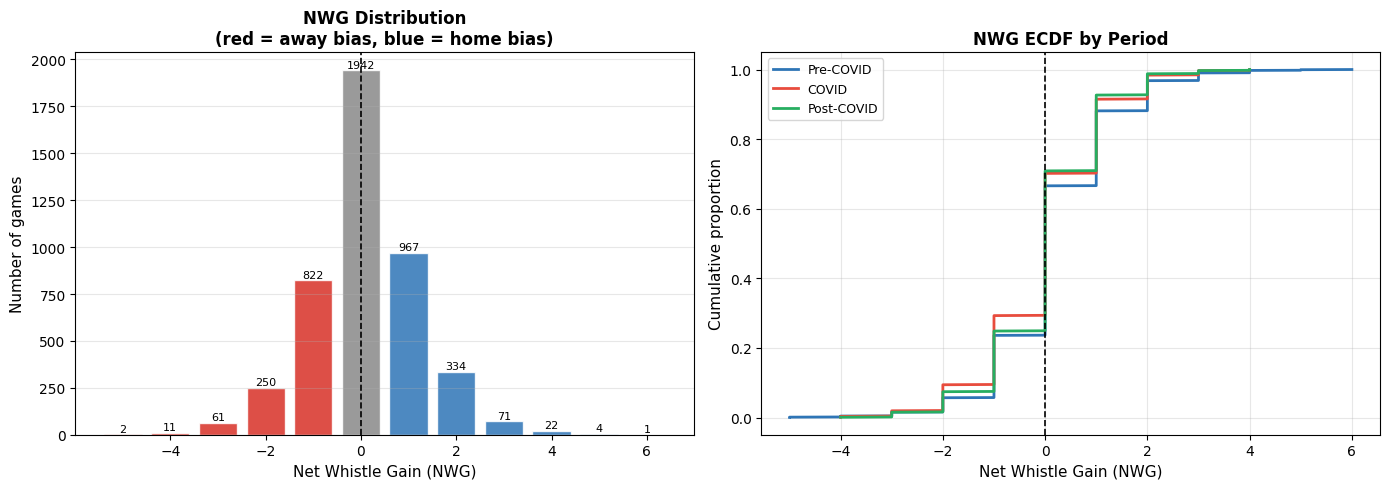

In [90]:
print(f"\nNWG distribution:")
print(master['NWG'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — NWG distribution bar chart
nwg_counts = master['NWG'].value_counts().sort_index()
colors = ['#d73027' if x < 0 else '#2E75B6' if x > 0 else '#888888' 
          for x in nwg_counts.index]
axes[0].bar(nwg_counts.index, nwg_counts.values, color=colors, 
            alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', lw=1.2)
axes[0].set_xlabel('Net Whistle Gain (NWG)', fontsize=11)
axes[0].set_ylabel('Number of games', fontsize=11)
axes[0].set_title('NWG Distribution\n(red = away bias, blue = home bias)', 
                  fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for x, y in zip(nwg_counts.index, nwg_counts.values):
    axes[0].text(x, y + 15, str(y), ha='center', fontsize=8)

# Right — cumulative % by period
for per, color in [('Pre-COVID','#2E75B6'),('COVID','#E84C3D'),('Post-COVID','#27AE60')]:
    sub = master[master['period']==per]['NWG'].sort_values()
    ecdf = np.arange(1, len(sub)+1) / len(sub)
    axes[1].plot(sub, ecdf, color=color, lw=2, label=per)
axes[1].axvline(0, color='black', linestyle='--', lw=1.2)
axes[1].set_xlabel('Net Whistle Gain (NWG)', fontsize=11)
axes[1].set_ylabel('Cumulative proportion', fontsize=11)
axes[1].set_title('NWG ECDF by Period', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/output/nwg_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observation** — The NWG distribution is right-skewed: 1,399 games have NWG > 0 (home bias) versus 1,146 games with NWG < 0 (away bias), with 1,942 games at NWG = 0. The ECDF confirms the temporal pattern — the Pre-COVID distribution is shifted rightward relative to COVID and Post-COVID, indicating a higher frequency of home-bias games in that period. COVID and Post-COVID curves are nearly indistinguishable at the game level.

### 6.2 Cover Rate Baseline

The distribution of `home_covered` is examined to establish the baseline cover rate for the L2M sample. A baseline below 50% is expected — bookmakers price home advantage into the spread regardless of officiating.

In [91]:
cover = master.dropna(subset=['home_covered'])

print("=== Cover rate baseline ===")
print(cover['home_covered'].value_counts())
print(f"\nCover rate:  {cover['home_covered'].mean():.4f}")
print(f"Total games: {len(cover)}")
print(f"Pushes:      {master['home_covered'].isna().sum()}")
print()
print("=== Cover rate by period ===")
print(cover.groupby('period', observed=True)['home_covered'].agg(['mean','count']).round(3))
print()
print("=== Cover rate by playoff ===")
print(cover.groupby('playoff')['home_covered'].agg(['mean','count']).round(3))

=== Cover rate baseline ===
home_covered
0.0    2612
1.0    1766
Name: count, dtype: int64

Cover rate:  0.4034
Total games: 4378
Pushes:      109

=== Cover rate by period ===
             mean  count
period                  
COVID       0.406   1198
Post-COVID  0.387   1299
Pre-COVID   0.413   1881

=== Cover rate by playoff ===
          mean  count
playoff              
0        0.411   4099
1        0.290    279


> **Observation** — The baseline cover rate is 40.3% across 4,378 games with a valid cover outcome. This is below 50% for all groups — consistent with the L2M sample consisting exclusively of close games where bookmakers have already priced in home advantage. The cover rate declines across periods: Pre-COVID (41.3%), COVID (40.6%), Post-COVID (38.7%). Playoff games show the lowest cover rate (28.6%) compared to regular season (41.2%), indicating that bookmakers systematically over-price home teams in playoff close games.

### 6.3 Spread Distribution

The distribution of `spread` is examined to understand the range of pre-game market expectations across the sample.

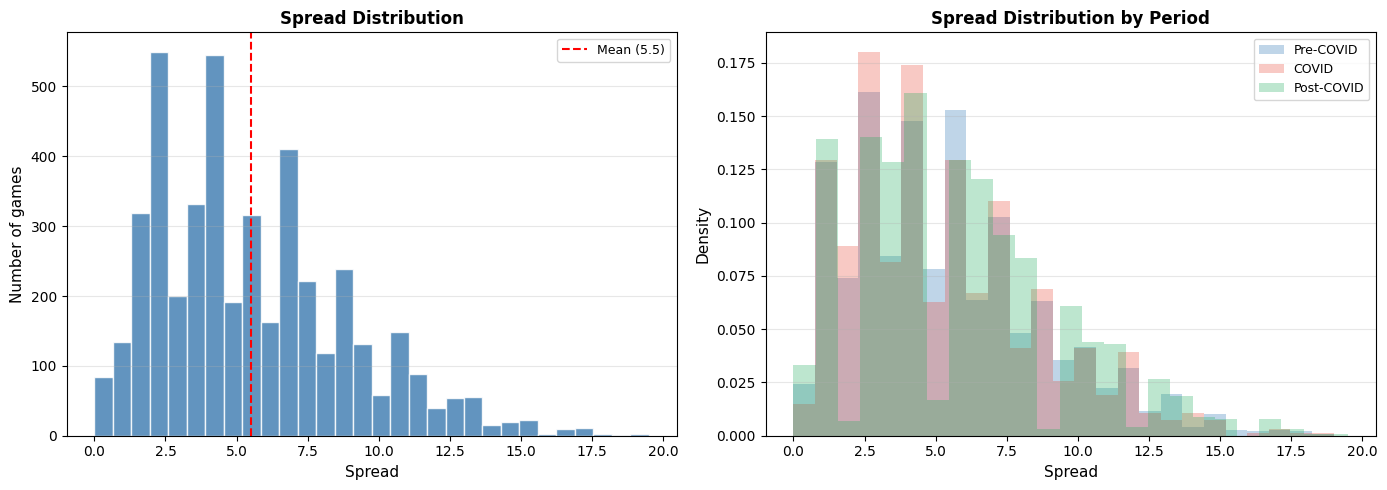

0        0.0
1        8.0
2        4.5
3        5.5
4        6.5
        ... 
4482     5.5
4483     6.5
4484     6.5
4485    10.5
4486     8.5
Name: spread, Length: 4487, dtype: float64


In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — spread histogram
axes[0].hist(master['spread'].dropna(), bins=30, 
             color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Spread', fontsize=11)
axes[0].set_ylabel('Number of games', fontsize=11)
axes[0].set_title('Spread Distribution', fontsize=12, fontweight='bold')
axes[0].axvline(master['spread'].mean(), color='red', linestyle='--', 
                lw=1.5, label=f'Mean ({master["spread"].mean():.1f})')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Right — spread by period
for per, color in [('Pre-COVID','#2E75B6'),('COVID','#E84C3D'),('Post-COVID','#27AE60')]:
    sub = master[master['period']==per]['spread'].dropna()
    axes[1].hist(sub, bins=25, alpha=0.3, color=color, label=per, density=True)
axes[1].set_xlabel('Spread', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Spread Distribution by Period', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/output/spread_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(master['spread'].sort_index())

> **Observation** — The spread distribution shows periodic peaks at 3.5, 5.5, and 7.5 points — half-point values preferred by bookmakers to avoid push outcomes. The mean spread is 5.5 points. The distribution is right-skewed, reflecting that most L2M games are close contests with small spreads.

### 6.4 Market Overreaction

The cover rate at NWG > 0 is examined to test whether the market systematically over-prices home advantage in high-pressure close games.

In [93]:
# Cover rate by NWG group and period
# Groups NWG into 6 bins and computes the home cover rate
# for each combination of NWG group and period.
master_cover = master.dropna(subset=['home_covered']).copy()
master_cover['NWG_group'] = pd.cut(master_cover['NWG'],
    bins=[-20,-2,-1,0,1,2,20],
    labels=['≤-2','−1','0','+1','+2','≥+3'])

print("=== Cover rate by NWG group and period ===")
pivot = master_cover.groupby(
    ['NWG_group', 'period'], observed=True
)['home_covered'].mean().unstack() * 100
print(pivot.round(1).to_string())

=== Cover rate by NWG group and period ===
period     COVID  Post-COVID  Pre-COVID
NWG_group                              
≤-2         37.2        44.3       45.3
−1          40.4        36.9       44.2
0           41.4        39.0       42.4
+1          42.0        38.2       39.4
+2          37.0        37.5       38.7
≥+3         36.8        37.5       22.8


> **Observation** — Cover rate decreases monotonically with NWG in the Pre-COVID period: from 45.3% at $NWG \leq -2$ down to 22.8% at $NWG \geq +3$. The COVID and Post-COVID periods show the same directional pattern above $NWG = 0$, but the gradient is shallower. In all three periods, the $NWG \geq +3$ group has the lowest cover rate.

### 6.5 NWG and Spread Joint Distribution

The joint distribution of NWG and spread is examined to test whether games with higher referee bias coincide with specific spread ranges — a visual check of the Structural Convergence hypothesis.

#### 6.5.1 By Period

The question is simple: do bookmakers set higher spreads for games that later turn out to have more referee errors favouring the home team? To check this, games are split into three groups — those where referees favoured the away team (NWG < 0), those with no net bias (NWG = 0), and those where referees favoured the home team (NWG > 0) — and the average spread is compared across groups. If the market anticipated referee bias, the NWG > 0 group would consistently show the highest spreads.

The bivariate density of NWG and spread is estimated separately for each temporal period. A horizontal shift in the density peak indicates a change in the central tendency of referee bias; a vertical shift indicates a change in the spread range of games captured by the L2M reports.

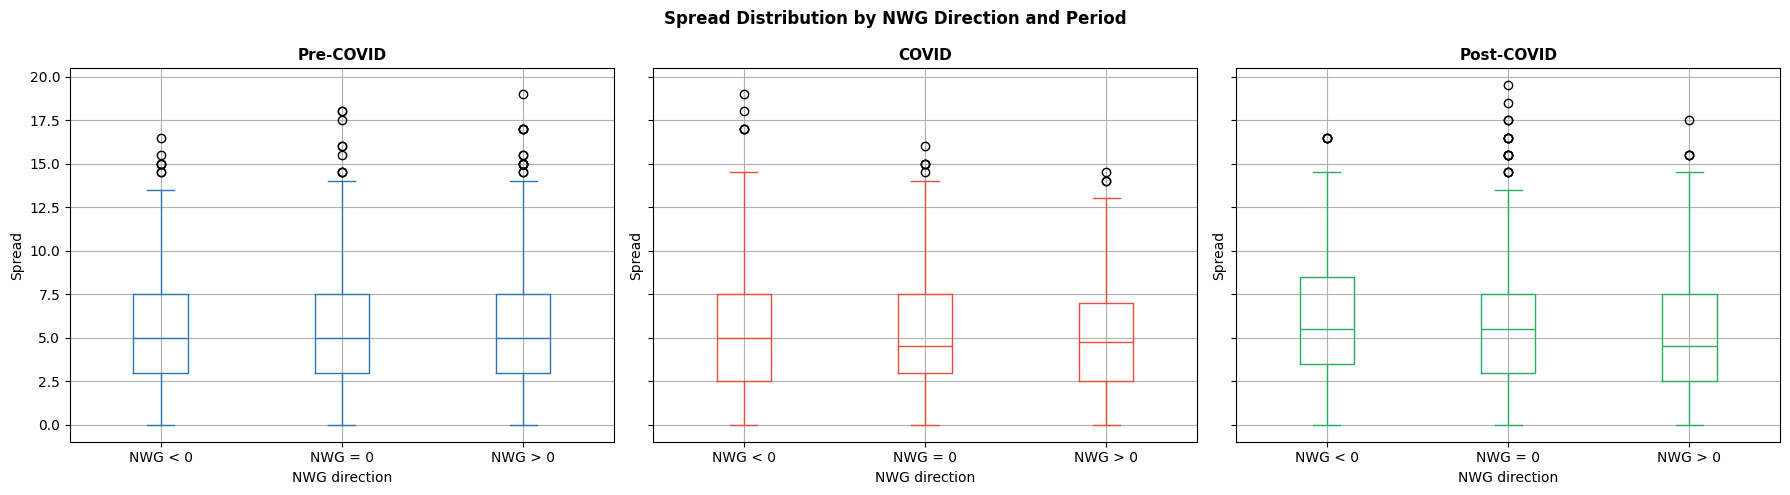

                          mean  median   std  count
period     NWG_direction                           
COVID      NWG < 0        5.52    5.00  3.53    364
           NWG = 0        5.30    4.50  3.21    507
           NWG > 0        5.19    4.75  3.03    370
Post-COVID NWG < 0        6.13    5.50  3.57    325
           NWG = 0        5.82    5.50  3.59    602
           NWG > 0        5.42    4.50  3.32    381
Pre-COVID  NWG < 0        5.35    5.00  3.21    457
           NWG = 0        5.63    5.00  3.41    832
           NWG > 0        5.37    5.00  3.37    647


In [94]:
# Box plot of spread by NWG direction and period. Each box shows the interquartile range of the pre-game spread for games grouped by referee bias direction. Similar medians across NWG groups would indicate that bookmakers do not price referee bias into the spread.

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

periods = ['Pre-COVID', 'COVID', 'Post-COVID']
colors  = ['#2E75B6', '#E84C3D', '#27AE60']

for ax, period, color in zip(axes, periods, colors):
    subset = master[master['period'] == period]
    subset.boxplot(column='spread', by='NWG_direction', ax=ax, color=color)
    ax.set_title(period, fontsize=11, fontweight='bold')
    ax.set_xlabel('NWG direction', fontsize=10)
    ax.set_ylabel('Spread', fontsize=10)

plt.suptitle('Spread Distribution by NWG Direction and Period', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/output/boxplot_spread_nwg.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics of spread by NWG direction and period
master['NWG_direction'] = pd.cut(master['NWG'], bins=[-20, -1, 0, 20], labels=['NWG < 0', 'NWG = 0', 'NWG > 0'])
print(master.groupby(['period', 'NWG_direction'], observed=True)['spread'].agg(['mean', 'median', 'std', 'count']).round(2))

> **Observation** — In Pre-COVID the averages are 5.35, 5.63, and 5.37 points respectively. In COVID: 5.52, 5.30, and 5.19. In Post-COVID: 6.13, 5.82, and 5.42. The NWG > 0 group never has the highest spread — in two out of three periods it has the lowest. Bookmakers do not price referee bias into the spread.

The box plots show points above the upper whisker. The upper whisker is calculated by matplotlib as Q3 + 1.5*IQR — points above it are shown separately. This code identifies where the whisker ends and how many games fall above it, so we can investigate whether they are legitimate games or data errors.

In [95]:
Q1 = master['spread'].quantile(0.25)
Q3 = master['spread'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
n_above = (master['spread'] > upper_fence).sum()
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}, upper fence={upper_fence}, n above={n_above}")

Q1=3.0, Q3=7.5, IQR=4.5, upper fence=14.25, n above=73


In [96]:
# Investigate games with spread above 14 points
high_spread = master[master['spread'] > 14][['date', 'home', 'away', 'spread', 'NWG', 'playoff', 'period', 'score_diff']].sort_values('spread', ascending=False)
print(f"Games with spread > 14: {len(high_spread)}")
print(high_spread.to_string())

Games with spread > 14: 73
            date home away  spread  NWG  playoff      period  score_diff
3601  2023-04-02  MIN  POR    19.5    0        0  Post-COVID        -2.0
2285  2020-08-04  MIL  BKN    19.0   -1        0       COVID        -3.0
280   2015-12-18  GSW  MIL    19.0    2        0   Pre-COVID         9.0
4451  2025-04-08  IND  WAS    18.5    0        0  Post-COVID         6.0
105   2015-04-13  LAC  DEN    18.0    0        0   Pre-COVID         7.0
2121  2020-01-01  MIL  MIN    18.0   -2        0       COVID         2.0
38    2015-03-16  GSW  LAL    18.0    0        0   Pre-COVID         3.0
4001  2024-04-01  ORL  POR    17.5    0        0  Post-COVID         1.0
3805  2023-12-28  BOS  DET    17.5    0        0  Post-COVID         6.0
1430  2018-03-30  HOU  PHX    17.5    0        0   Pre-COVID         1.0
4453  2025-04-09  GSW  SAS    17.5    4        0  Post-COVID        -3.0
1823  2019-03-10  GSW  PHX    17.0    1        0   Pre-COVID        -4.0
913   2017-03-14  GSW  P

> **Observation** — The box plots show games above the upper whisker (Q3 + 1.5×IQR = 14.25 points, n=73). To check whether these are data errors or legitimate games, they are extracted and examined. All 73 are regular season games between a strong and a weak opponent — GSW, BOS, MIL и CLE се появяват многократно като домакини, докато LAL, PHI, DET и NYK като гости. NWG варира между -3 и +4, consistent with the rest of the sample. They are retained in the analysis.

#### 6.5.2 By Playoff Status

Playoff games are played between teams that have already qualified — by definition a more balanced field than the regular season. The box plot from 6.5.1 showed 73 games above the upper whisker, all from the regular season. Here the same split is examined by playoff status to confirm whether high-spread games are structurally absent from the playoffs.

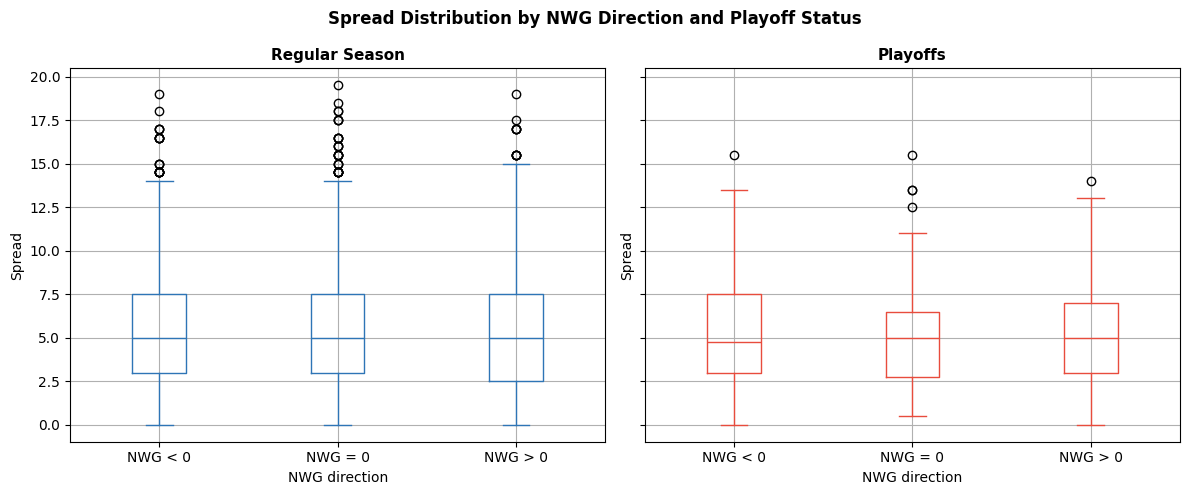

                       mean  median   std  count
playoff NWG_direction                           
0       NWG < 0        5.64    5.00  3.44   1080
        NWG = 0        5.63    5.00  3.45   1830
        NWG > 0        5.35    5.00  3.30   1290
1       NWG < 0        5.42    4.75  3.32     66
        NWG = 0        5.12    5.00  2.94    111
        NWG > 0        5.16    5.00  2.86    108

Playoff games above per-group upper whisker (n=6):
            date home away  spread  NWG      period
1004  2017-05-21  CLE  BOS    15.5   -1   Pre-COVID
4472  2025-04-26  MEM  OKC    15.5    0  Post-COVID
551   2016-04-18  OKC  DAL    14.0    1   Pre-COVID
573   2016-05-11  GSW  POR    13.5    0   Pre-COVID
1908  2019-04-15  GSW  LAC    13.5    0   Pre-COVID
3638  2023-04-26  MIL  MIA    12.5    0  Post-COVID


In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

playoff_labels = {0: 'Regular Season', 1: 'Playoffs'}
colors = ['#2E75B6', '#E84C3D']

for ax, (playoff, label), color in zip(axes, playoff_labels.items(), colors):
    subset = master[master['playoff'] == playoff]
    subset.boxplot(column='spread', by='NWG_direction', ax=ax, color=color)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('NWG direction', fontsize=10)
    ax.set_ylabel('Spread', fontsize=10)

plt.suptitle('Spread Distribution by NWG Direction and Playoff Status', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/output/boxplot_spread_nwg_playoff.png', dpi=150, bbox_inches='tight')
plt.show()

print(master.groupby(['playoff', 'NWG_direction'], observed=True)['spread'].agg(['mean', 'median', 'std', 'count']).round(2))

above_whisker_playoff = []
for group in ['NWG < 0', 'NWG = 0', 'NWG > 0']:
    subset = master[(master['playoff'] == 1) & (master['NWG_direction'] == group)]
    Q1 = subset['spread'].quantile(0.25)
    Q3 = subset['spread'].quantile(0.75)
    IQR = Q3 - Q1
    upper_fence_g = Q3 + 1.5 * IQR
    above = subset[subset['spread'] > upper_fence_g][['date', 'home', 'away', 'spread', 'NWG', 'period']]
    above_whisker_playoff.append(above)

result = pd.concat(above_whisker_playoff).sort_values('spread', ascending=False)
print(f"\nPlayoff games above per-group upper whisker (n={len(result)}):")
print(result.to_string())

> **Observation** — Playoff games are more compact than regular season games. Mean spread across all three NWG groups sits between 5.12 and 5.42 points, compared to 5.35–5.64 in the regular season — playoff teams are more evenly matched by definition. The box plot shows 5 visible points above the per-group upper whiskers (6 games total, two pairs share the same spread value of 13.5 and 15.5 points and appear as single points). These are legitimate mismatches — CLE vs BOS (15.5), MEM vs OKC (15.5), OKC vs DAL (14.0), GSW vs POR (13.5), GSW vs LAC (13.5), MIL vs MIA (12.5). As in the regular season, spread and NWG direction are uncorrelated in the playoffs — mean spread is virtually identical across NWG < 0, NWG = 0, and NWG > 0 groups.

### 6.6 Correlation Structure

The master dataset contains 36 columns. Before proceeding to the analysis, the pairwise associations between all variables (excluding `gid`) are examined using Cramér's V — a measure of association between categorical variables based on the chi-square statistic, suitable for discrete and categorical data. Values close to 1.0 indicate strong association; values close to 0 indicate independence. A strong association between `NWG` and `spread` would indicate confounding between the two primary variables.

In [98]:
print(master.select_dtypes(include=['object', 'bool', 'category']).columns.tolist())
print(master.select_dtypes(include=['int64', 'float64']).columns.tolist())


['away', 'away_team', 'date', 'home', 'home_team', 'national_tv', 'whos_favored', 'period', 'NWG_direction', 'id_spread_match', 'score_home_match', 'score_away_match']
['ATTENDANCE', 'away_score', 'gid', 'home_score', 'playoff', 'season', 'beta', 'delta', 'home_IC', 'home_INC', 'away_IC', 'away_INC', 'n_plays', 'spread', 'id_spread', 'home_fav', 'home_covered', 'score_diff', 'NWG', 'AR', 'spread_signed', 'cover_check']


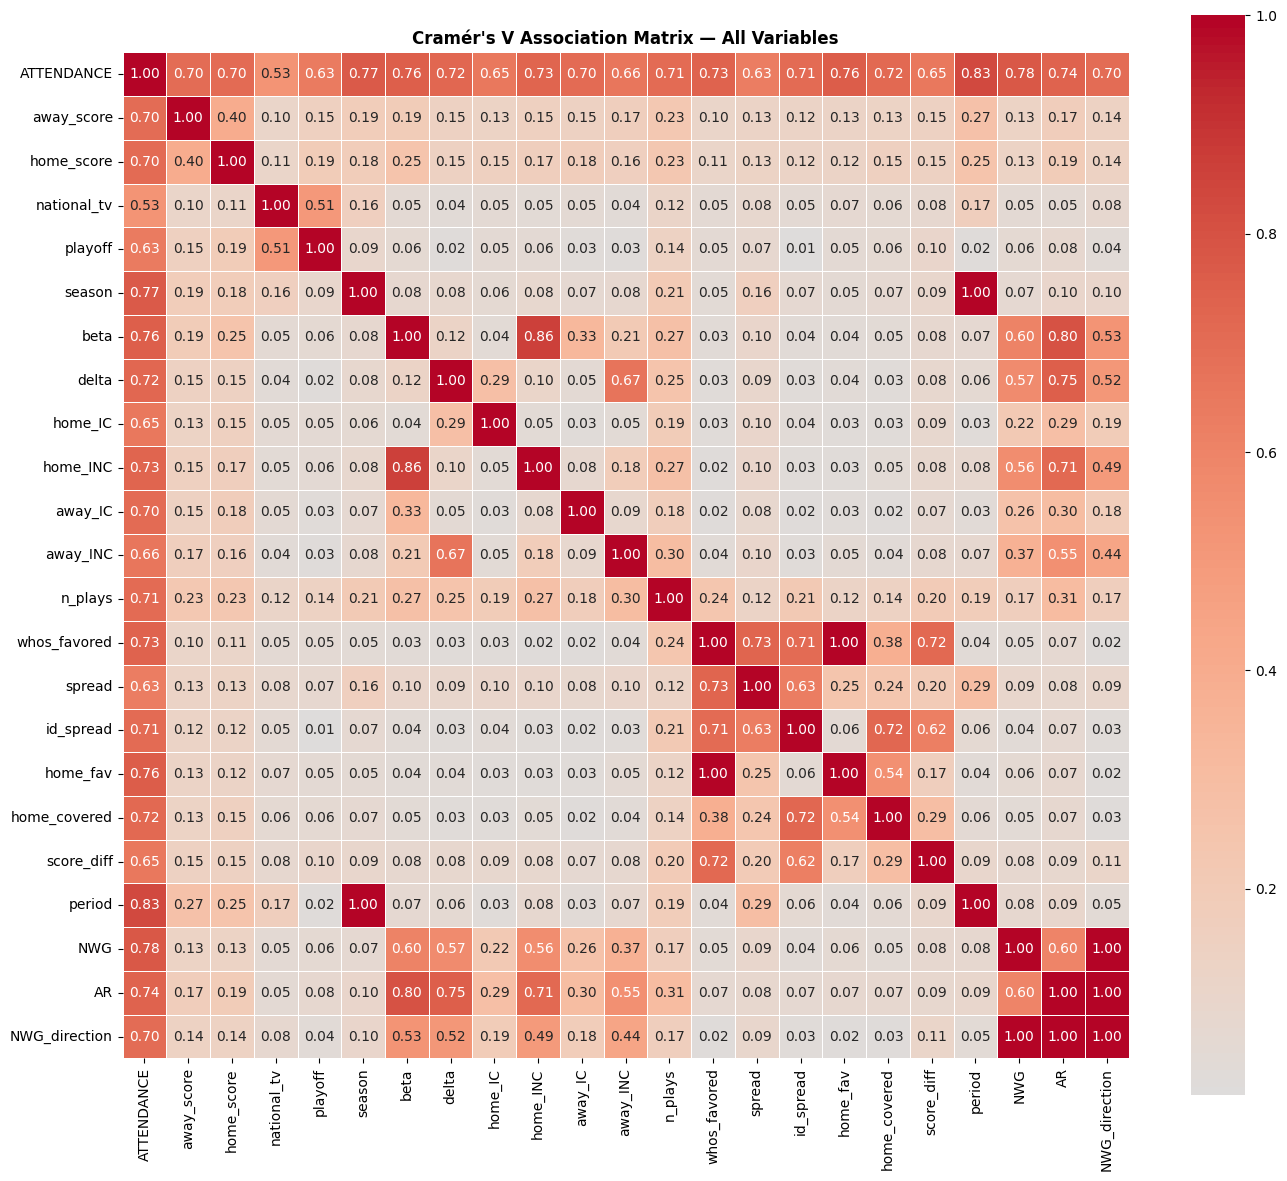

In [99]:
from scipy.stats import chi2_contingency
import itertools

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

exclude = ['gid', 'date', 'home', 'away', 'home_team', 'away_team', 'score_home_match', 'score_away_match', 'id_spread_match', 'spread_signed', 'cover_check', 'score_home', 'score_away']
cols = [c for c in master.columns if c not in exclude]

cramers_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
for col1, col2 in itertools.product(cols, cols):
    cramers_matrix.loc[col1, col2] = cramers_v(master[col1].astype(str), master[col2].astype(str))

plt.figure(figsize=(14, 12))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title("Cramér's V Association Matrix — All Variables", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/output/cramers_v_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observation** — The goal is to identify unexpected associations between analytical variables before formal testing. Three patterns stand out.

> First, `NWG`, `AR`, and `NWG_direction` are perfectly associated (V=1.00) — they are three representations of the same quantity and only one should enter any model.

> Second, `ATTENDANCE` shows a strong association with almost every variable in the matrix, including `period` (V=0.83), `season` (V=0.77), `beta` (V=0.76), and `NWG` (V=0.78). This is not a crowd pressure signal — it reflects two structural confounds: COVID seasons have near-zero attendance by design, and arena capacities have grown over time. `ATTENDANCE` is not an independent proxy for crowd pressure and is excluded from the regression model in Section 7.3.

> Third, the two primary variables of interest show weak association: `NWG` and `spread` (V=0.09), confirming the finding from Section 6.5 that bookmakers do not price referee bias into the spread. `home_covered` and `NWG` show V=0.07 — a weak but non-zero association between referee bias and cover outcome.

## 7. Analysis

### 7.1 Auxiliary Hypothesis — Monte Carlo Simulation

The Monte Carlo simulation tests whether referee errors systematically favour the home team. Following Pelechrinis (2023), for each play in `auxiliary_data` we simulate the decision outcome based on call-type base rates, then compute the expected NWG under the null hypothesis (no systematic bias). The empirical p-value is the proportion of simulations where the simulated NWG exceeds the observed t_real.

### 7.2 KS Test — Temporal Periods

The Kolmogorov-Smirnov test compares the null distributions across the three periods to determine whether the structural conditions changed over time.

### 7.3 Central Hypothesis — Betting Market Analysis

The central hypothesis is tested through three methods: binomial test, NWG group analysis, and logistic regression.

## 8. Limitations

Several limitations should be considered when interpreting the results.

The L2M dataset covers only close games — games within 5 points in the last two minutes. This introduces a selection bias: the sample is not representative of all NBA games, and findings may not generalize to non-close games.

The Monte Carlo simulation uses 10,000 runs, which produces stable empirical p-values for moderate effect sizes but may underestimate significance for very large effects (reporting p < 0.001 rather than exact values).

Multiple hypothesis tests are conducted without Bonferroni correction, following Pelechrinis (2023) [PelechrinisL2M], which increases the risk of Type I error inflation.

The COVID period (2021–2022) conflates two potentially distinct conditions — games with zero attendance and games with restricted capacity. These are treated as a single period for simplicity.

SRS from Basketball Reference is a season-level measure and does not capture within-season variation in team strength, unlike the game-level ELO ratings.

Player and referee names were excluded from the dataset on ethical grounds. As a result, player-level bias analysis relies on career-level PER groupings rather than individual identification, which limits the granularity of the findings.

## 9. References

[PelechrinisL2M] Pelechrinis, K. (2023). Quantifying implicit biases in refereeing using NBA referees as a testbed. *Scientific Reports*, 13, 4664. https://doi.org/10.1038/s41598-023-31799-y  
[PelechrinisCode] Pelechrinis, K. (2023). NBA-ref-analysis. GitHub. https://github.com/kpelechrinis/NBA-ref-analysis  
[AtlhawksfanaticL2M] atlhawksfanatic. (2025). L2M: NBA Last Two Minute Reports. GitHub. https://github.com/atlhawksfanatic/L2M  
[FansidedNBA] FanSided. (2024). How many games are in the NBA season? https://fansided.com/posts/how-many-games-are-in-the-nba-season-01j8kcxt31rr  
[ErikstadJohansen2020] Erikstad, M. K., & Johansen, B. T. (2020). Referee bias in professional football: Favoritism toward successful teams in potential penalty situations. Frontiers in Sports and Active Living, 2, 19. https://doi.org/10.3389/fspor.2020.00019  
[Barrett2021] Barrett, D. (2021). Star player bias in the NBA: A quantile regression approach. Empirical Economics Bulletin, 14(1), 9. 
[Rothman1990] Rothman, K. J. (1990). No adjustments are needed for multiple  comparisons. Epidemiology, 1(1), 43–46. https://doi.org/10.1097/00001648-199001000-00010
[BelasenL2M2025] Belasen, A.R., Belasen, A.T., & Olbrecht, A. (2025). With the game on the (betting) line: NBA referee performance in the last two minutes. *Journal of Sports Economics*. https://doi.org/10.1177/15270025251369447
[Fama1970] Fama, E.F. (1970). Efficient capital markets: A review of theory and empirical work. *Journal of Finance*, 25(2), 383–417.
[Levitt2004] Levitt, S. (2004). Why are gambling markets organised so differently from financial markets? *The Economic Journal*, 114, 223–246.
[KaggleBetting] cviaxmiwnptr. (2025). NBA Betting Data | October 2007 to June 2025. Kaggle. https://www.kaggle.com/datasets/cviaxmiwnptr/nba-betting-data-october-2007-to-june-2024
